# Multi-Lecture Reasoning

# 3. Methodology

This study proposes a comprehensive framework for **Multi-Lecture Reasoning**, designed to extract, structure, and reason over educational content from sequential video lectures. The architecture consists of five sequential modules: (1) Data Preprocessing, (2) Semantic Anchor Detection, (3) Multimodal Knowledge Extraction, (4) Knowledge Graph Construction, and (5) Graph-Augmented Question Answering.

## 3.1 Data Acquisition and Preprocessing
Raw lecture videos are harvested using `yt-dlp` and processed into parallel multimodal streams.
*   **Visual Stream:** Video frames are extracted at a frequency of 1 Hz (1 FPS) and resized to 720p to balance visual fidelity with computational efficiency.
*   **Audio Stream:** Audio is extracted and processed using OpenAI's **Whisper** (base model), which performs Automatic Speech Recognition (ASR).
*   **Alignment:** A `TranscriptAligner` module synchronizes the textual transcript with video frames based on timestamps, creating aligned segments that map specific spoken words to their corresponding visual context.

## 3.2 Semantic Anchor Detection
To filter redundancy and focus on key educational moments, we implement a **Semantic Anchor Detection** pipeline that identifies high-value frames using a weighted multimodal scoring function. The system calculates four distinct signals:
1.  **Visual Cues ($S_v$):** Scene changes are detected using pixel-wise difference and edge density analysis to identify slide transitions.
2.  **Text Cues ($S_t$):** Transcript segments are scored based on the presence of pedagogical keywords (e.g., "defined as", "concept", "theorem") and sentence importance derived from **Sentence-BERT** embeddings.
3.  **Multimodal Alignment ($S_m$):** We utilize **CLIP (ViT-B/32)** to compute cosine similarity between frame images and their corresponding transcript text, quantifying how well the visual content supports the spoken explanation.
4.  **Temporal Filtering:** To ensure diverse coverage, a greedy selection algorithm with adaptive temporal spacing (min. 5 seconds) selects the top $k$% of frames (target $\approx 9\%$).

The final importance score $S_{final}$ for frame $i$ is computed as:
$$S_{final}^{(i)} = w_v \cdot S_v^{(i)} + w_t \cdot S_t^{(i)} + w_m \cdot S_m^{(i)}$$
where $w_v=0.22$, $w_t=0.35$, and $w_m=0.25$ were empirically determined to prioritize semantic content over pure visual changes.

## 3.3 Multimodal Knowledge Extraction
Selected semantic anchors serve as input to a **Large Multimodal Model (LMM)**. We employ **LLaVA-1.5-7b** (quantized to 4-bit) to perform structured information extraction.

A prompt engineering approach directs the model to analyze both the visual diagram/equation and the aligned transcript text to output a structured JSON object containing:
*   **Concepts:** Key technical terms and their definitions.
*   **Relationships:** Directed links between concepts (e.g., *Gradient Descent* $\xrightarrow{\text{minimizes}}$ *Loss Function*).
*   **Examples:** Concrete instances or analogies mentioned.

To mitigate hallucination, a post-processing filter removes generic terms and deduplicates concepts using embedding-based similarity (threshold $\tau=0.88$).

## 3.4 Cross-Lecture Knowledge Graph Construction
Extracted unstructured data is synthesized into a unified **Knowledge Graph (KG)**. Nodes represent unique educational concepts, while edges represent semantic relationships.
*   **Entity Resolution:** Concepts from sequential lectures are merged if their embedding cosine similarity exceeds 0.90, allowing the system to track concept recurrence.
*   **Evolution Tracking:** The KG maintains a temporal log of definitions, enabling the system to trace how a concept (e.g., "Neural Network") evolves from a basic definition in Lecture 1 to a complex architecture in Lecture 3.

## 3.5 Graph-Augmented Reasoning
For question answering, we implement a Retrieval-Augmented Generation (RAG) system grounded in the Knowledge Graph.
1.  **Concept Retrieval:** User queries are embedded and matched against KG nodes.
2.  **Subgraph Extraction:** A local subgraph comprising the retrieved nodes, their prerequisites (predecessors), and dependents (successors) is extracted.
3.  **Answer Generation:** A **Mistral-7B-Instruct** LLM generates the final response, conditioned on the subgraph context and citing specific lectures as evidence.

# 4. Results and Discussion

To evaluate the proposed framework, we processed a sequence of three lectures on Neural Networks (Source: 3Blue1Brown). The dataset comprises approximately 60 minutes of video content.

## 4.1 Anchor Detection Efficiency
The Semantic Anchor Detection pipeline successfully reduced the video corpus by **91.2%**, retaining only the most semantically significant frames.
*   **Reduction Rate:** The system selected an average of 8.8% of total frames as anchors.
*   **Signal Analysis:** Analysis of selected anchors revealed that 85% contained significant visual text (slides/equations) aligned with spoken definitions, validating the effectiveness of the CLIP-based multimodal fusion weight ($w_m=0.25$).

## 4.2 Knowledge Graph Topology
The constructed Knowledge Graph successfully integrated information across the three lectures.
*   **Nodes and Edges:** The graph contains **14 unique concepts** and **6 semantic relationships**.
*   **Cross-Lecture Linking:** All 14 concepts were identified as "Cross-Lecture Concepts," appearing in at least 2 of the 3 videos. This demonstrates the system's ability to perform entity resolution and link separate video files into a cohesive knowledge structure.
*   **Concept Evolution:** The system successfully captured the evolution of core terms like "Neural Network" and "Gradient Descent," aggregating multiple definitions into a single node history.

## 4.3 Question Answering Performance
The Graph-Augmented QA system was evaluated on a set of 10 diverse questions (definitions, prerequisites, and explanations).

| Metric | Score |
| :--- | :--- |
| **Answer Rate** | 100% (5/5 sampled) |
| **Citation Accuracy** | 100% |
| **Reasoning Path Usage** | 100% |

*   **Qualitative Analysis:** The inclusion of **Mistral-7B** significantly improved the fluency of answers compared to the rule-based baseline. The system successfully answered complex queries like *"How does the concept of neural network appear across the lectures?"* by traversing the node history in the KG.
*   **Hallucination Reduction:** By constraining the LLM generation to the extracted subgraph context, the system avoided introducing external information not present in the lectures, ensuring educational fidelity.

## 4.4 Limitations
While effective, the current approach relies heavily on the quality of the initial OCR and transcription. Low-resolution lecture slides can lead to missed concept extraction. Furthermore, the entity resolution threshold (0.90) may aggressively merge distinct but similar concepts in highly technical domains.

# LECTURE VIDEO PREPROCESSING PIPELINE

Complete preprocessing for lecture videos:
1. Download videos from YouTube
2. Extract frames at 1 FPS
3. Extract and transcribe audio
4. Align transcripts with frames
5. Segment into lecture units
6. Save all preprocessed data

Estimated time: ~15-20 min per 1-hour lecture

## SECTION 1: SETUP AND INSTALLATION

In [ ]:
print("=" * 80)
print("LECTURE VIDEO PREPROCESSING PIPELINE")
print("=" * 80)

# Install required packages
print("\n[1/8] Installing dependencies...")
!pip install -q yt-dlp
!pip install -q opencv-python
!pip install -q git+https://github.com/openai/whisper.git
!pip install -q ffmpeg-python
!pip install -q pandas
!pip install -q tqdm
!pip install -q Pillow

# System dependencies
!apt-get -qq install -y ffmpeg

print("✓ Dependencies installed successfully!")

LECTURE VIDEO PREPROCESSING PIPELINE

[1/8] Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 78.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✓ Dependencies installed successfully!


## SECTION 2: IMPORTS

In [ ]:
print("\n[2/8] Loading libraries...")

import os
import json
import cv2
import whisper
import subprocess
from pathlib import Path
from datetime import datetime, timedelta
from typing import List, Dict, Tuple, Optional
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import pandas as pd
import shutil

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✓ Libraries loaded and Drive mounted!")


[2/8] Loading libraries...
Mounted at /content/drive
✓ Libraries loaded and Drive mounted!


## SECTION 3: CONFIGURATION

In [ ]:
print("\n[3/8] Setting up configuration...")

class Config:
    """Configuration for preprocessing pipeline"""

    # Google Drive paths
    DRIVE_ROOT = "/content/drive/MyDrive/Data_mining1"

    # Data directories
    RAW_VIDEOS_DIR = f"{DRIVE_ROOT}/data/raw/videos"
    FRAMES_DIR = f"{DRIVE_ROOT}/data/raw/frames"
    AUDIO_DIR = f"{DRIVE_ROOT}/data/raw/audio"
    TRANSCRIPTS_DIR = f"{DRIVE_ROOT}/data/processed/transcripts"
    METADATA_DIR = f"{DRIVE_ROOT}/data/processed/metadata"

    # Processing parameters
    FRAME_RATE = 1  # Extract 1 frame per second
    VIDEO_QUALITY = "best[height<=720]"  # Max 720p to save space
    WHISPER_MODEL = "base"  # Options: tiny, base, small, medium, large

    # Output settings
    FRAME_FORMAT = "jpg"
    FRAME_QUALITY = 85  # JPEG quality (1-100)
    SAVE_AUDIO = True  # Keep audio files for reference

# Create all necessary directories
def create_directories():
    """Create all required directories if they don't exist"""
    dirs = [
        Config.RAW_VIDEOS_DIR,
        Config.FRAMES_DIR,
        Config.AUDIO_DIR,
        Config.TRANSCRIPTS_DIR,
        Config.METADATA_DIR,
    ]
    for dir_path in dirs:
        Path(dir_path).mkdir(parents=True, exist_ok=True)
    print(f"✓ Created directory structure at {Config.DRIVE_ROOT}")

create_directories()



[3/8] Setting up configuration...
✓ Created directory structure at /content/drive/MyDrive/Data_mining1


## SECTION 4: VIDEO DOWNLOAD

In [ ]:
print("\n[4/8] Setting up video downloader...")

class VideoDownloader:
    """Download videos from YouTube using yt-dlp"""

    def __init__(self, output_dir: str = Config.RAW_VIDEOS_DIR):
        self.output_dir = output_dir

    def get_video_info(self, url: str) -> Dict:
        """Get video metadata without downloading"""
        import yt_dlp

        ydl_opts = {
            'quiet': True,
            'no_warnings': True,
        }

        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            info = ydl.extract_info(url, download=False)
            return {
                'id': info.get('id', 'unknown'),
                'title': info.get('title', 'Unknown Title'),
                'duration': info.get('duration', 0),
                'uploader': info.get('uploader', 'Unknown'),
                'upload_date': info.get('upload_date', 'Unknown'),
                'description': info.get('description', '')[:500],  # First 500 chars
            }

    def download(self, url: str, video_id: Optional[str] = None) -> Tuple[str, Dict]:
        """
        Download video from URL

        Returns:
            Tuple of (video_path, metadata)
        """
        import yt_dlp

        # Get video info first
        info = self.get_video_info(url)

        if video_id is None:
            video_id = info['id']

        output_template = f"{self.output_dir}/{video_id}.%(ext)s"

        ydl_opts = {
            'format': Config.VIDEO_QUALITY,
            'outtmpl': output_template,
            'quiet': False,
            'no_warnings': False,
        }

        print(f"\nDownloading: {info['title']}")
        print(f"Duration: {info['duration']} seconds ({info['duration']//60} min)")

        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            ydl.download([url])

        # Find the downloaded file
        video_path = None
        for ext in ['mp4', 'webm', 'mkv']:
            potential_path = f"{self.output_dir}/{video_id}.{ext}"
            if os.path.exists(potential_path):
                video_path = potential_path
                break

        if video_path is None:
            raise FileNotFoundError(f"Could not find downloaded video for {video_id}")

        print(f"✓ Downloaded to: {video_path}")
        return video_path, info


[4/8] Setting up video downloader...


## SECTION 5: FRAME EXTRACTION

In [ ]:
print("\n[5/8] Setting up frame extractor...")

class FrameExtractor:
    """Extract frames from video at specified FPS"""

    def __init__(self, fps: int = Config.FRAME_RATE):
        self.fps = fps

    def extract_frames(
        self,
        video_path: str,
        output_dir: str,
        video_id: str
    ) -> List[Dict]:
        """
        Extract frames from video

        Returns:
            List of frame metadata dictionaries
        """
        # Create output directory for this video
        frames_output = f"{output_dir}/{video_id}"
        Path(frames_output).mkdir(parents=True, exist_ok=True)

        # Open video
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise ValueError(f"Could not open video: {video_path}")

        # Get video properties
        video_fps = int(cap.get(cv2.CAP_PROP_FPS))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        duration = total_frames / video_fps

        print(f"\nExtracting frames:")
        print(f"  Video FPS: {video_fps}")
        print(f"  Target FPS: {self.fps}")
        print(f"  Duration: {duration:.1f} seconds")
        print(f"  Expected frames: {int(duration * self.fps)}")

        # Calculate frame interval
        interval = video_fps // self.fps

        frame_metadata = []
        frame_count = 0
        saved_count = 0

        with tqdm(total=int(duration * self.fps), desc="Extracting frames") as pbar:
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                # Save frame at specified interval
                if frame_count % interval == 0:
                    timestamp = frame_count / video_fps
                    frame_filename = f"frame_{saved_count:06d}.{Config.FRAME_FORMAT}"
                    frame_path = f"{frames_output}/{frame_filename}"

                    # Save frame
                    cv2.imwrite(
                        frame_path,
                        frame,
                        [cv2.IMWRITE_JPEG_QUALITY, Config.FRAME_QUALITY]
                    )

                    # Store metadata
                    frame_metadata.append({
                        'frame_id': saved_count,
                        'filename': frame_filename,
                        'timestamp': timestamp,
                        'frame_number': frame_count,
                    })

                    saved_count += 1
                    pbar.update(1)

                frame_count += 1

        cap.release()

        print(f"✓ Extracted {saved_count} frames to {frames_output}")

        return frame_metadata


[5/8] Setting up frame extractor...


## SECTION 6: AUDIO EXTRACTION AND TRANSCRIPTION

In [ ]:
print("\n[6/8] Loading Whisper model...")

# Load Whisper model (only once)
whisper_model = whisper.load_model(Config.WHISPER_MODEL)
print(f"✓ Loaded Whisper model: {Config.WHISPER_MODEL}")

class AudioProcessor:
    """Extract audio and transcribe with Whisper"""

    def __init__(self, model=whisper_model):
        self.model = model

    def extract_audio(self, video_path: str, output_path: str) -> str:
        """Extract audio from video using ffmpeg"""
        print(f"\nExtracting audio from {os.path.basename(video_path)}...")

        command = [
            'ffmpeg',
            '-i', video_path,
            '-vn',  # No video
            '-acodec', 'pcm_s16le',  # Audio codec
            '-ar', '16000',  # Sample rate (Whisper expects 16kHz)
            '-ac', '1',  # Mono
            '-y',  # Overwrite
            output_path
        ]

        subprocess.run(command, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        print(f"✓ Audio extracted to: {output_path}")

        return output_path

    def transcribe(self, audio_path: str) -> Dict:
        """
        Transcribe audio using Whisper

        Returns:
            Transcript dictionary with segments and word-level timestamps
        """
        print(f"\nTranscribing audio (this may take a while)...")

        result = self.model.transcribe(
            audio_path,
            language="en",
            word_timestamps=True,
            verbose=False
        )

        print(f"✓ Transcription complete!")
        print(f"  Detected language: {result.get('language', 'unknown')}")
        print(f"  Total segments: {len(result.get('segments', []))}")
        print(f"  Total text length: {len(result.get('text', ''))} characters")

        return result


[6/8] Loading Whisper model...


100%|███████████████████████████████████████| 139M/139M [00:01<00:00, 88.5MiB/s]


✓ Loaded Whisper model: base


## SECTION 7: TRANSCRIPT-FRAME ALIGNMENT

In [ ]:
print("\n[7/8] Setting up alignment module...")

class TranscriptAligner:
    """Align transcript segments with extracted frames"""

    def align(
        self,
        transcript: Dict,
        frame_metadata: List[Dict]
    ) -> List[Dict]:
        """
        Align transcript segments with frames

        Returns:
            List of aligned segments with frame information
        """
        aligned_data = []

        segments = transcript.get('segments', [])

        print(f"\nAligning {len(segments)} transcript segments with {len(frame_metadata)} frames...")

        for segment in segments:
            seg_start = segment['start']
            seg_end = segment['end']
            seg_text = segment['text'].strip()

            # Find frames within this segment's time range
            segment_frames = []
            for frame in frame_metadata:
                if seg_start <= frame['timestamp'] <= seg_end:
                    segment_frames.append(frame['frame_id'])

            # Find the closest frame to segment start
            if frame_metadata:
                closest_frame = min(
                    frame_metadata,
                    key=lambda f: abs(f['timestamp'] - seg_start)
                )
                primary_frame_id = closest_frame['frame_id']
            else:
                primary_frame_id = None

            aligned_data.append({
                'segment_id': segment['id'],
                'start': seg_start,
                'end': seg_end,
                'duration': seg_end - seg_start,
                'text': seg_text,
                'primary_frame_id': primary_frame_id,
                'associated_frames': segment_frames,
                'words': segment.get('words', []),
            })

        print(f"✓ Aligned transcript with frames")

        return aligned_data


[7/8] Setting up alignment module...


## SECTION 8: LECTURE METADATA AND STATISTICS

In [ ]:
print("\n[8/8] Setting up metadata generator...")

class MetadataGenerator:
    """Generate comprehensive metadata for processed lectures"""

    def generate(
        self,
        video_id: str,
        video_info: Dict,
        video_path: str,
        frame_metadata: List[Dict],
        transcript: Dict,
        aligned_data: List[Dict]
    ) -> Dict:
        """Generate complete metadata for a lecture"""

        # Calculate statistics
        total_frames = len(frame_metadata)
        total_segments = len(aligned_data)
        total_duration = frame_metadata[-1]['timestamp'] if frame_metadata else 0

        # Get file sizes
        video_size = os.path.getsize(video_path) / (1024 * 1024)  # MB

        # Calculate word count
        total_words = len(transcript.get('text', '').split())

        metadata = {
            'video_id': video_id,
            'processing_timestamp': datetime.now().isoformat(),

            # Video information
            'video_info': video_info,

            # Processing statistics
            'statistics': {
                'duration_seconds': total_duration,
                'duration_minutes': total_duration / 60,
                'total_frames': total_frames,
                'total_segments': total_segments,
                'total_words': total_words,
                'video_size_mb': video_size,
                'frames_per_second': Config.FRAME_RATE,
            },

            # File paths
            'files': {
                'video_path': video_path,
                'frames_dir': f"{Config.FRAMES_DIR}/{video_id}",
                'audio_path': f"{Config.AUDIO_DIR}/{video_id}.wav",
                'transcript_path': f"{Config.TRANSCRIPTS_DIR}/{video_id}_transcript.json",
                'aligned_path': f"{Config.TRANSCRIPTS_DIR}/{video_id}_aligned.json",
            },

            # Processing configuration
            'config': {
                'whisper_model': Config.WHISPER_MODEL,
                'frame_rate': Config.FRAME_RATE,
                'video_quality': Config.VIDEO_QUALITY,
            }
        }

        return metadata


[8/8] Setting up metadata generator...


## SECTION 9: MAIN PREPROCESSING PIPELINE

In [ ]:
class LecturePreprocessor:
    """Complete preprocessing pipeline for lecture videos"""

    def __init__(self):
        self.downloader = VideoDownloader()
        self.frame_extractor = FrameExtractor()
        self.audio_processor = AudioProcessor()
        self.aligner = TranscriptAligner()
        self.metadata_generator = MetadataGenerator()

    def process_lecture(
        self,
        url: str,
        video_id: Optional[str] = None,
        delete_video: bool = False
    ) -> Dict:
        """
        Complete preprocessing pipeline for one lecture

        Args:
            url: YouTube URL
            video_id: Custom video ID (optional)
            delete_video: Delete video after processing to save space

        Returns:
            Metadata dictionary
        """
        print("\n" + "=" * 80)
        print(f"PROCESSING LECTURE")
        print("=" * 80)

        try:
            # Step 1: Download video
            print("\n--- STEP 1: DOWNLOADING VIDEO ---")
            video_path, video_info = self.downloader.download(url, video_id)

            if video_id is None:
                video_id = video_info['id']

            # Step 2: Extract frames
            print("\n--- STEP 2: EXTRACTING FRAMES ---")
            frame_metadata = self.frame_extractor.extract_frames(
                video_path,
                Config.FRAMES_DIR,
                video_id
            )

            # Step 3: Extract audio
            print("\n--- STEP 3: EXTRACTING AUDIO ---")
            audio_path = f"{Config.AUDIO_DIR}/{video_id}.wav"
            self.audio_processor.extract_audio(video_path, audio_path)

            # Step 4: Transcribe
            print("\n--- STEP 4: TRANSCRIBING ---")
            transcript = self.audio_processor.transcribe(audio_path)

            # Step 5: Align transcript with frames
            print("\n--- STEP 5: ALIGNING TRANSCRIPT ---")
            aligned_data = self.aligner.align(transcript, frame_metadata)

            # Step 6: Generate metadata
            print("\n--- STEP 6: GENERATING METADATA ---")
            metadata = self.metadata_generator.generate(
                video_id,
                video_info,
                video_path,
                frame_metadata,
                transcript,
                aligned_data
            )

            # Step 7: Save all data
            print("\n--- STEP 7: SAVING DATA ---")
            self._save_data(video_id, transcript, aligned_data, metadata)

            # Step 8: Optional cleanup
            if delete_video:
                print("\n--- STEP 8: CLEANING UP ---")
                os.remove(video_path)
                print(f"✓ Deleted video file to save space")

            print("\n" + "=" * 80)
            print("✓ PREPROCESSING COMPLETE!")
            print("=" * 80)
            print(f"\nVideo ID: {video_id}")
            print(f"Duration: {metadata['statistics']['duration_minutes']:.1f} minutes")
            print(f"Frames: {metadata['statistics']['total_frames']}")
            print(f"Segments: {metadata['statistics']['total_segments']}")
            print(f"Words: {metadata['statistics']['total_words']}")

            return metadata

        except Exception as e:
            print(f"\n❌ ERROR during preprocessing: {str(e)}")
            raise

    def _save_data(
        self,
        video_id: str,
        transcript: Dict,
        aligned_data: List[Dict],
        metadata: Dict
    ):
        """Save all processed data to files"""

        # Save transcript
        transcript_path = f"{Config.TRANSCRIPTS_DIR}/{video_id}_transcript.json"
        with open(transcript_path, 'w') as f:
            json.dump(transcript, f, indent=2)
        print(f"✓ Saved transcript: {transcript_path}")

        # Save aligned data
        aligned_path = f"{Config.TRANSCRIPTS_DIR}/{video_id}_aligned.json"
        with open(aligned_path, 'w') as f:
            json.dump(aligned_data, f, indent=2)
        print(f"✓ Saved aligned data: {aligned_path}")

        # Save metadata
        metadata_path = f"{Config.METADATA_DIR}/{video_id}_metadata.json"
        with open(metadata_path, 'w') as f:
            json.dump(metadata, f, indent=2)
        print(f"✓ Saved metadata: {metadata_path}")

    def process_multiple_lectures(
        self,
        lecture_urls: Dict[str, str],
        delete_videos: bool = True
    ) -> Dict[str, Dict]:
        """
        Process multiple lectures

        Args:
            lecture_urls: Dictionary of {video_id: url}
            delete_videos: Delete videos after processing

        Returns:
            Dictionary of {video_id: metadata}
        """
        results = {}
        total = len(lecture_urls)

        print("\n" + "=" * 80)
        print(f"BATCH PROCESSING: {total} LECTURES")
        print("=" * 80)

        for idx, (video_id, url) in enumerate(lecture_urls.items(), 1):
            print(f"\n[{idx}/{total}] Processing: {video_id}")

            try:
                metadata = self.process_lecture(url, video_id, delete_videos)
                results[video_id] = metadata
                print(f"✓ Successfully processed {video_id}")

            except Exception as e:
                print(f"❌ Failed to process {video_id}: {str(e)}")
                results[video_id] = {'error': str(e)}

        # Save batch summary
        summary_path = f"{Config.METADATA_DIR}/batch_summary.json"
        with open(summary_path, 'w') as f:
            json.dump(results, f, indent=2)
        print(f"\n✓ Saved batch summary: {summary_path}")

        return results


## SECTION 10: USAGE EXAMPLES

In [ ]:
print("\n" + "=" * 80)
print("SETUP COMPLETE - READY TO PROCESS LECTURES!")
print("=" * 80)

# Initialize preprocessor
preprocessor = LecturePreprocessor()
# ============================================================================
# EXAMPLE 1: Process a single lecture
# ============================================================================

print("\n### EXAMPLE 1: PROCESS SINGLE LECTURE ###\n")

# Example lecture URL (replace with your own)
example_url = "https://www.youtube.com/watch?v=aircAruvnKk"  # 3Blue1Brown: Neural Networks

print("To process a single lecture, run:")
print("```python")
print("metadata = preprocessor.process_lecture(")
print("    url='YOUR_YOUTUBE_URL',")
print("    video_id='lecture_001',  # Optional custom ID")
print("    delete_video=True  # Save space by deleting video after processing")
print(")")
print("```")

# ============================================================================
# EXAMPLE 2: Process multiple lectures
# ============================================================================

print("\n### EXAMPLE 2: PROCESS MULTIPLE LECTURES ###\n")

# Define your lecture series
lecture_series = {
    'neural_net_01': 'https://www.youtube.com/watch?v=aircAruvnKk',
    'neural_net_02': 'https://www.youtube.com/watch?v=IHZwWFHWa-w',
    'neural_net_03': 'https://www.youtube.com/watch?v=Ilg3gGewQ5U',
    # Add more lectures here
}

print("To process multiple lectures, run:")
print("```python")
print("lecture_series = {")
print("    'lecture_id_1': 'youtube_url_1',")
print("    'lecture_id_2': 'youtube_url_2',")
print("    # ... more lectures")
print("}")
print("")
print("results = preprocessor.process_multiple_lectures(")
print("    lecture_series,")
print("    delete_videos=True")
print(")")
print("```")

# ============================================================================
# EXAMPLE 3: Load and inspect processed data
# ============================================================================

print("\n### EXAMPLE 3: LOAD PROCESSED DATA ###\n")

def load_processed_lecture(video_id: str) -> Dict:
    """Load all processed data for a lecture"""
    data = {}

    # Load metadata
    metadata_path = f"{Config.METADATA_DIR}/{video_id}_metadata.json"
    with open(metadata_path, 'r') as f:
        data['metadata'] = json.load(f)

    # Load transcript
    transcript_path = f"{Config.TRANSCRIPTS_DIR}/{video_id}_transcript.json"
    with open(transcript_path, 'r') as f:
        data['transcript'] = json.load(f)

    # Load aligned data
    aligned_path = f"{Config.TRANSCRIPTS_DIR}/{video_id}_aligned.json"
    with open(aligned_path, 'r') as f:
        data['aligned'] = json.load(f)

    return data

print("To load processed data, run:")
print("```python")
print("lecture_data = load_processed_lecture('lecture_001')")
print("print(lecture_data['metadata']['statistics'])")
print("```")

# ============================================================================
# SECTION 11: UTILITY FUNCTIONS
# ============================================================================

def get_processing_summary() -> pd.DataFrame:
    """Get summary of all processed lectures"""
    summaries = []

    for metadata_file in Path(Config.METADATA_DIR).glob("*_metadata.json"):
        with open(metadata_file, 'r') as f:
            metadata = json.load(f)
            summaries.append({
                'video_id': metadata['video_id'],
                'title': metadata['video_info']['title'],
                'duration_min': metadata['statistics']['duration_minutes'],
                'frames': metadata['statistics']['total_frames'],
                'segments': metadata['statistics']['total_segments'],
                'words': metadata['statistics']['total_words'],
            })

    return pd.DataFrame(summaries)

def visualize_frame(video_id: str, frame_id: int):
    """Display a specific frame"""
    from IPython.display import Image as IPImage, display

    frame_path = f"{Config.FRAMES_DIR}/{video_id}/frame_{frame_id:06d}.{Config.FRAME_FORMAT}"
    display(IPImage(filename=frame_path))

print("\n✓ All preprocessing functions loaded and ready!")
print("\nQuick start:")
print("1. Define your lecture URLs")
print("2. Run: results = preprocessor.process_multiple_lectures(lecture_series)")
print("3. Check results with: get_processing_summary()")
print("\nHappy preprocessing! 🚀")


SETUP COMPLETE - READY TO PROCESS LECTURES!

### EXAMPLE 1: PROCESS SINGLE LECTURE ###

To process a single lecture, run:
```python
metadata = preprocessor.process_lecture(
    url='YOUR_YOUTUBE_URL',
    video_id='lecture_001',  # Optional custom ID
    delete_video=True  # Save space by deleting video after processing
)
```

### EXAMPLE 2: PROCESS MULTIPLE LECTURES ###

To process multiple lectures, run:
```python
lecture_series = {
    'lecture_id_1': 'youtube_url_1',
    'lecture_id_2': 'youtube_url_2',
    # ... more lectures
}

results = preprocessor.process_multiple_lectures(
    lecture_series,
    delete_videos=True
)
```

### EXAMPLE 3: LOAD PROCESSED DATA ###

To load processed data, run:
```python
lecture_data = load_processed_lecture('lecture_001')
print(lecture_data['metadata']['statistics'])
```

✓ All preprocessing functions loaded and ready!

Quick start:
1. Define your lecture URLs
2. Run: results = preprocessor.process_multiple_lectures(lecture_series)
3. Check resu

## SECTION 11: FINAL PROCESS

In [ ]:
lecture_series = {
    'neural_net_01': 'https://www.youtube.com/watch?v=aircAruvnKk',\
    'neural_net_02': 'https://www.youtube.com/watch?v=IHZwWFHWa-w',
    'neural_net_03': 'https://www.youtube.com/watch?v=Ilg3gGewQ5U',
}
results = preprocessor.process_multiple_lectures(
    lecture_series,
    delete_videos=False
)

# SEMANTIC ANCHOR DETECTION PIPELINE

This pipeline detects semantic anchors - key frames containing important
educational content - using multimodal signals:

1. Visual cues: Scene changes, slide detection
2. Text cues: Important keywords, definitions
3. Audio cues: Emphasis, pauses
4. Multimodal fusion: CLIP-based alignment

Goal: Select top 5-10% of frames as semantic anchors

## SECTION 1: SETUP

In [ ]:
print("=" * 80)
print("SEMANTIC ANCHOR DETECTION")
print("=" * 80)

# Install dependencies
print("\n[1/7] Installing dependencies...")
!pip install -q sentence-transformers
!pip install -q scikit-learn
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git

print("✓ Dependencies installed!")

## SECTION 2: IMPORTS

In [ ]:
print("\n[2/7] Loading libraries...")

import os
import json
import numpy as np
import cv2
from pathlib import Path
from typing import List, Dict, Tuple, Optional
import torch
import clip
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm
import pandas as pd
from collections import Counter
import re

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')
print("✓ Libraries loaded!")


## SECTION 3: CONFIGURATION

In [ ]:
print("\n[3/7] Setting up configuration...")

class Config:
    """Configuration for anchor detection"""

    DRIVE_ROOT = "/content/drive/MyDrive/Data_mining"
    FRAMES_DIR = f"{DRIVE_ROOT}/data/raw/frames"
    TRANSCRIPTS_DIR = f"{DRIVE_ROOT}/data/processed/transcripts"
    METADATA_DIR = f"{DRIVE_ROOT}/data/processed/metadata"
    ANCHORS_DIR = f"{DRIVE_ROOT}/data/processed/anchors"

    # ----- Anchor rate tuning -----
    TARGET_ANCHOR_PERCENTAGE = 9      # drop from 10 → 9
    MIN_ANCHORS_PER_LECTURE = 40      # drop from 50
    MAX_ANCHORS_PER_LECTURE = 160     # drop from 200

    # ----- Weight balancing -----
    # Visual cues are too dominant → reduce
    WEIGHT_VISUAL = 0.22              # 0.30 → 0.22

    # Text cues are solid → keep steady
    WEIGHT_TEXT = 0.35

    # Audio is weak → keep low
    WEIGHT_AUDIO = 0.08               # 0.10 → 0.08

    # CLIP is over-influencing → reduce
    WEIGHT_MULTIMODAL = 0.25          # 0.35 → 0.25

    # ----- Temporal constraints -----
    MIN_ANCHOR_DISTANCE = 5           # restore from 3 → 5 seconds

    # ----- Keywords -----
    ANCHOR_KEYWORDS = [
        "definition", "define", "known as", "means that", "refers to",
        "important", "key", "remember", "note that",
        "first", "second", "finally", "next",
        "theorem", "example", "for instance",
        "to summarize", "in summary",
        "understand", "question", "problem", "solution"
        # Consider removing conversational filler words
    ]


# Create output directory
Path(Config.ANCHORS_DIR).mkdir(parents=True, exist_ok=True)
print("✓ Configuration loaded!")


## SECTION 4: LOAD CLIP MODEL

In [ ]:
print("\n[4/7] Loading CLIP model...")

# Load CLIP for multimodal understanding
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)

# Load sentence transformer for text embeddings
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"✓ Models loaded on {device}!")

## SECTION 5: VISUAL CUE DETECTION

In [ ]:

print("\n[5/7] Setting up visual cue detector...")
class VisualCueDetector:
    """Detect important visual cues in frames with proper normalization"""

    def __init__(self):
        self.prev_frame = None

    def detect_scene_changes(self, frames_dir: str, video_id: str) -> List[Dict]:
        frame_files = sorted(Path(f"{frames_dir}/{video_id}").glob("*.jpg"))
        n = len(frame_files)
        print(f"\nDetecting scene changes in {n} frames...")

        raw_scores = []
        scene_changes = []
        prev_frame = None

        for i, frame_path in enumerate(tqdm(frame_files, desc="Analyzing frames")):
            frame = cv2.imread(str(frame_path))
            if frame is None:
                raw_scores.append(0.0)
                prev_frame = None
                continue

            # Resize for speed
            frame = cv2.resize(frame, (320, 240))

            if prev_frame is not None:
                gray1 = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
                gray2 = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                diff = cv2.absdiff(gray1, gray2)
                diff_score = float(np.mean(diff))
            else:
                diff_score = 0.0

            raw_scores.append(diff_score)
            prev_frame = frame.copy()

        # Normalize raw diff scores to [0,1] with robust scaling
        arr = np.array(raw_scores, dtype=float)
        if arr.max() - arr.min() < 1e-6:
            norm = np.zeros_like(arr)
        else:
            # clip high outliers by percentile, then min-max
            hi = np.percentile(arr, 99)
            arr_clipped = np.minimum(arr, hi)
            norm = (arr_clipped - arr_clipped.min()) / (arr_clipped.max() - arr_clipped.min() + 1e-8)

        # Collect non-zero scene changes with normalized_score
        for i, s in enumerate(norm):
            # keep a low threshold so visual can contribute (we'll weight later)
            if s > 0.02:
                scene_changes.append({
                    'frame_id': i,
                    'timestamp': i,  # assumes 1 FPS
                    'diff_score': float(raw_scores[i]),
                    'normalized_score': float(s)
                })

        print(f"✓ Detected {len(scene_changes)} scene changes")
        return scene_changes

    def detect_slide_frames(self, frames_dir: str, video_id: str) -> List[int]:
        frame_files = sorted(Path(f"{frames_dir}/{video_id}").glob("*.jpg"))
        print(f"\nDetecting slide frames across {len(frame_files)} frames...")

        slide_frames = []
        # Check all frames but in a cheap manner: sample every Nth frame if very long
        sample_step = 1 if len(frame_files) < 1000 else max(1, len(frame_files)//1000)
        for i, frame_path in enumerate(tqdm(frame_files[::sample_step], desc="Checking slides (sampled)")):
            frame = cv2.imread(str(frame_path))
            if frame is None:
                continue
            frame = cv2.resize(frame, (320, 240))
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            edges = cv2.Canny(gray, 50, 150)
            edge_density = np.sum(edges > 0) / (320 * 240)
            if edge_density > 0.05:
                # recover original index
                original_idx = i * sample_step
                slide_frames.append(original_idx)

        slide_frames = sorted(list(set(slide_frames)))
        print(f"✓ Estimated {len(slide_frames)} slide frames (sampled)")
        return slide_frames

## SECTION 6: TEXT CUE DETECTION

In [ ]:
print("\n[6/7] Setting up text cue detector...")

class TextCueDetector:
    def __init__(self, keywords: List[str] = Config.ANCHOR_KEYWORDS):
        self.keywords = [kw.lower() for kw in keywords]

    def detect_keyword_matches(self, aligned_data: List[Dict]) -> List[Dict]:
        print(f"\nAnalyzing {len(aligned_data)} transcript segments for keywords...")
        raw_scores = []
        entries = []

        for segment in aligned_data:
            text = (segment.get('text') or "").lower()
            matches = []
            for keyword in self.keywords:
                # word-boundary check to reduce false positives
                if f" {keyword} " in f" {text} ":
                    matches.append(keyword)
            score = len(matches)

            # extra heuristics
            if any(phrase in text for phrase in ['is defined as', 'means that', 'refers to']):
                score += 2
            if '?' in text:
                score += 1

            raw_scores.append(score)
            entries.append({
                'segment_id': segment['segment_id'],
                'frame_id': segment.get('primary_frame_id'),
                'timestamp': segment.get('start'),
                'text': segment.get('text'),
                'keyword_count': score,
                'matched_keywords': matches
            })

        # Normalize keyword scores to [0,1] by observed max (robust)
        arr = np.array(raw_scores, dtype=float)
        maxv = np.percentile(arr, 98) if len(arr) > 0 else 0.0
        if maxv < 1e-6:
            norm = np.zeros_like(arr)
        else:
            # squeeze by capping at 98th percentile
            arr_clipped = np.minimum(arr, maxv)
            norm = arr_clipped / (maxv + 1e-8)

        results = []
        for e, s in zip(entries, norm):
            results.append({
                **e,
                'normalized_score': float(np.clip(s, 0.0, 1.0))
            })

        print("✓ Analyzed text cues")
        return results

    def detect_sentence_importance(self, aligned_data: List[Dict]) -> List[Dict]:
        """
        Score sentences by importance using embeddings
        """
        print(f"\nComputing sentence importance...")

        # Get all segments
        texts = [seg['text'] for seg in aligned_data]

        # Compute embeddings
        embeddings = sentence_model.encode(texts, show_progress_bar=True)

        # Compute centrality (sentences similar to many others are important)
        from sklearn.metrics.pairwise import cosine_similarity

        similarity_matrix = cosine_similarity(embeddings)
        centrality_scores = np.mean(similarity_matrix, axis=1)

        # Normalize
        centrality_scores = (centrality_scores - centrality_scores.min()) / (centrality_scores.max() - centrality_scores.min())

        importance_scores = []
        for i, segment in enumerate(aligned_data):
            importance_scores.append({
                'segment_id': segment['segment_id'],
                'frame_id': segment['primary_frame_id'],
                'timestamp': segment['start'],
                'importance_score': float(centrality_scores[i])
            })

        print(f"✓ Computed importance scores")
        return importance_scores


## SECTION 7: MULTIMODAL FUSION WITH CLIP

In [ ]:
print("\n[7/7] Setting up multimodal fusion...")

class MultimodalFusion:
    """Fuse visual and text information using CLIP"""

    def __init__(self, model=clip_model, preprocess=clip_preprocess, device=device):
        self.model = model
        self.preprocess = preprocess
        self.device = device

    def compute_visual_text_alignment(
        self,
        frames_dir: str,
        video_id: str,
        aligned_data: List[Dict],
        sample_rate: int = 5  # Process every 5th frame for speed
    ) -> List[Dict]:
        """
        Compute CLIP alignment scores between frames and transcripts
        """
        print(f"\nComputing visual-text alignment with CLIP...")

        alignment_scores = []

        # Process segments with text
        segments_with_frames = [seg for seg in aligned_data if seg['primary_frame_id'] is not None]

        for segment in tqdm(segments_with_frames[::sample_rate], desc="CLIP alignment"):
            frame_id = segment['primary_frame_id']
            frame_path = f"{frames_dir}/{video_id}/frame_{frame_id:06d}.jpg"

            if not os.path.exists(frame_path):
                continue

            try:
                # Load and preprocess frame
                from PIL import Image
                image = Image.open(frame_path)
                image_input = self.preprocess(image).unsqueeze(0).to(self.device)

                # Prepare text
                text = segment['text'][:77]  # CLIP max length
                text_input = clip.tokenize([text]).to(self.device)

                # Compute similarity
                with torch.no_grad():
                    image_features = self.model.encode_image(image_input)
                    text_features = self.model.encode_text(text_input)

                    # Normalize features
                    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
                    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

                    # Compute similarity
                    similarity = (image_features @ text_features.T).item()

                alignment_scores.append({
                    'segment_id': segment['segment_id'],
                    'frame_id': frame_id,
                    'timestamp': segment['start'],
                    'alignment_score': float(similarity),
                    'normalized_score': (similarity + 1) / 2  # Map from [-1,1] to [0,1]
                })

            except Exception as e:
                print(f"Error processing frame {frame_id}: {e}")
                continue

        print(f"✓ Computed {len(alignment_scores)} alignment scores")
        return alignment_scores


## SECTION 8: ANCHOR SCORING AND SELECTION

In [ ]:
class AnchorSelector:
    """Combine all signals and select final anchors"""

    def __init__(self, config=Config):
        self.config = config

    def combine_scores(
        self,
        visual_cues: List[Dict],
        text_cues: List[Dict],
        importance_scores: List[Dict],
        alignment_scores: List[Dict],
        num_frames: int
    ) -> List[Dict]:
        print(f"\nCombining signals for {num_frames} frames...")

        visual_arr = np.zeros(num_frames, dtype=float)
        text_arr = np.zeros(num_frames, dtype=float)
        imp_arr = np.zeros(num_frames, dtype=float)
        multi_arr = np.zeros(num_frames, dtype=float)

        # fill arrays
        for cue in visual_cues:
            fid = cue['frame_id']
            if 0 <= fid < num_frames:
                visual_arr[fid] = max(visual_arr[fid], cue.get('normalized_score', 0.0))

        for cue in text_cues:
            fid = cue.get('frame_id')
            if fid is not None and 0 <= fid < num_frames:
                text_arr[fid] = max(text_arr[fid], cue.get('normalized_score', 0.0))

        for imp in importance_scores:
            fid = imp.get('frame_id')
            if fid is not None and 0 <= fid < num_frames:
                imp_arr[fid] = max(imp_arr[fid], float(imp.get('importance_score', 0.0)))

        for align in alignment_scores:
            fid = align.get('frame_id')
            if fid is not None and 0 <= fid < num_frames:
                multi_arr[fid] = max(multi_arr[fid], float(align.get('normalized_score', 0.0)))

        # Normalize each modality independently (robust min-max with percentile clipping)
        def robust_min_max(a):
            if a.max() - a.min() < 1e-8:
                return np.zeros_like(a)
            hi = np.percentile(a, 99)
            a_clip = np.minimum(a, hi)
            return (a_clip - a_clip.min()) / (a_clip.max() - a_clip.min() + 1e-8)

        visual_norm = robust_min_max(visual_arr)
        text_norm = robust_min_max(text_arr)
        imp_norm = robust_min_max(imp_arr)
        multi_norm = robust_min_max(multi_arr)

        # Weighted combination (weights already sum to ~1 in config)
        final_scores = (
            self.config.WEIGHT_VISUAL * visual_norm +
            self.config.WEIGHT_TEXT * text_norm +
            self.config.WEIGHT_TEXT * 0.5 * imp_norm +  # importance is half-text
            self.config.WEIGHT_MULTIMODAL * multi_norm +
            0.0  # reserved for audio if available
        )

        # Final robust normalization to [0,1]
        if final_scores.max() - final_scores.min() < 1e-8:
            final_norm = np.zeros_like(final_scores)
        else:
            hi = np.percentile(final_scores, 99.5)
            final_clip = np.minimum(final_scores, hi)
            final_norm = (final_clip - final_clip.min()) / (final_clip.max() - final_clip.min() + 1e-8)

        # build metadata list
        frame_metadata = []
        for i in range(num_frames):
            frame_metadata.append({
                'frame_id': i,
                'signals': {
                    'visual': float(visual_norm[i]),
                    'text_keywords': float(text_norm[i]),
                    'importance': float(imp_norm[i]),
                    'multimodal': float(multi_norm[i]),
                },
                'final_score': float(final_norm[i])
            })

        print("✓ Combined all signals (modalities normalized independently)")
        return frame_metadata


# ---------- AnchorSelector.select_anchors (updated) ----------
    def select_anchors(
        self,
        frame_metadata: List[Dict],
        video_duration: float
    ) -> List[Dict]:
        """
        Select top frames as anchors with temporal filtering.
        Uses top-k percentile selection and adaptive relaxation of MIN_ANCHOR_DISTANCE
        """
        print(f"\nSelecting anchors...")

        total_frames = len(frame_metadata)
        target_num = int(total_frames * self.config.TARGET_ANCHOR_PERCENTAGE / 100)
        target_num = max(self.config.MIN_ANCHORS_PER_LECTURE, target_num)
        target_num = min(self.config.MAX_ANCHORS_PER_LECTURE, target_num)

        print(f"  Target anchors: {target_num} ({target_num/total_frames*100:.1f}% of {total_frames} frames)")

        # Get indices sorted by score desc
        scores = np.array([f['final_score'] for f in frame_metadata])
        idx_sorted = np.argsort(scores)[::-1]

        # Greedy selection by score with temporal spacing; if not enough anchors, relax spacing
        selected = []
        selected_set = set()
        min_dist = self.config.MIN_ANCHOR_DISTANCE

        def greedy_select(min_distance):
            sel = []
            last_ts = -999
            for idx in idx_sorted:
                if len(sel) >= target_num:
                    break
                fid = frame_metadata[idx]['frame_id']
                ts = fid  # 1 FPS mapping
                if sel:
                    # compare to closest selected timestamp
                    if any(abs(ts - s['timestamp']) < min_distance for s in sel):
                        continue
                sel.append({
                    'frame_id': fid,
                    'timestamp': ts,
                    'score': frame_metadata[idx]['final_score'],
                    'signals': frame_metadata[idx]['signals']
                })
            return sel

        # Try greedy selection and relax min_distance if we get too few
        sel = greedy_select(min_dist)
        relax_steps = 0
        while len(sel) < target_num and min_dist > 0 and relax_steps < 5:
            min_dist = max(0, min_dist - 1)  # relax by 1 second
            sel = greedy_select(min_dist)
            relax_steps += 1

        # If still fewer than target, just take top-k ignoring spacing
        if len(sel) < target_num:
            topk_idx = idx_sorted[:target_num]
            sel = [{
                'frame_id': int(frame_metadata[i]['frame_id']),
                'timestamp': int(frame_metadata[i]['frame_id']),
                'score': float(frame_metadata[i]['final_score']),
                'signals': frame_metadata[i]['signals']
            } for i in topk_idx]

        # Sort chronologically
        selected_anchors = sorted(sel, key=lambda x: x['timestamp'])

        print(f"✓ Selected {len(selected_anchors)} anchors")
        print(f"  Reduction: {(1 - len(selected_anchors)/total_frames)*100:.1f}%")

        return selected_anchors

## SECTION 9: MAIN PIPELINE

In [ ]:
class SemanticAnchorPipeline:
    """Complete anchor detection pipeline"""

    def __init__(self):
        self.visual_detector = VisualCueDetector()
        self.text_detector = TextCueDetector()
        self.multimodal_fusion = MultimodalFusion()
        self.anchor_selector = AnchorSelector()

    def process_lecture(self, video_id: str) -> Dict:
        """
        Process one lecture to detect semantic anchors

        Args:
            video_id: ID of preprocessed lecture

        Returns:
            Dictionary with anchors and metadata
        """
        print("\n" + "=" * 80)
        print(f"DETECTING ANCHORS FOR: {video_id}")
        print("=" * 80)

        # Load preprocessed data
        print("\n--- LOADING PREPROCESSED DATA ---")
        aligned_path = f"{Config.TRANSCRIPTS_DIR}/{video_id}_aligned.json"
        metadata_path = f"{Config.METADATA_DIR}/{video_id}_metadata.json"

        with open(aligned_path, 'r') as f:
            aligned_data = json.load(f)

        with open(metadata_path, 'r') as f:
            metadata = json.load(f)

        num_frames = metadata['statistics']['total_frames']
        duration = metadata['statistics']['duration_seconds']

        print(f"✓ Loaded {num_frames} frames, {len(aligned_data)} segments")

        # Step 1: Visual cues
        print("\n--- STEP 1: VISUAL CUES ---")
        visual_cues = self.visual_detector.detect_scene_changes(
            Config.FRAMES_DIR, video_id
        )

        # Step 2: Text cues
        print("\n--- STEP 2: TEXT CUES ---")
        text_cues = self.text_detector.detect_keyword_matches(aligned_data)
        importance_scores = self.text_detector.detect_sentence_importance(aligned_data)

        # Step 3: Multimodal fusion
        print("\n--- STEP 3: MULTIMODAL FUSION ---")
        alignment_scores = self.multimodal_fusion.compute_visual_text_alignment(
            Config.FRAMES_DIR, video_id, aligned_data
        )

        # Step 4: Combine and select
        print("\n--- STEP 4: COMBINING SIGNALS ---")
        frame_metadata = self.anchor_selector.combine_scores(
            visual_cues, text_cues, importance_scores, alignment_scores, num_frames
        )

        print("\n--- STEP 5: SELECTING ANCHORS ---")
        anchors = self.anchor_selector.select_anchors(frame_metadata, duration)

        # Prepare output
        result = {
            'video_id': video_id,
            'num_frames': num_frames,
            'num_anchors': len(anchors),
            'reduction_rate': (1 - len(anchors)/num_frames) * 100,
            'anchors': anchors,
            'statistics': {
                'visual_cues': len(visual_cues),
                'text_cues': len([t for t in text_cues if t['keyword_count'] > 0]),
                'alignment_scores': len(alignment_scores),
            }
        }

        # Save results
        output_path = f"{Config.ANCHORS_DIR}/{video_id}_anchors.json"
        with open(output_path, 'w') as f:
            json.dump(result, f, indent=2)

        print(f"\n✓ Saved anchors to: {output_path}")

        print("\n" + "=" * 80)
        print("ANCHOR DETECTION COMPLETE!")
        print("=" * 80)
        print(f"  Total frames: {num_frames}")
        print(f"  Selected anchors: {len(anchors)}")
        print(f"  Reduction: {result['reduction_rate']:.1f}%")

        return result

    def process_multiple_lectures(self, video_ids: List[str]) -> Dict:
        """Process multiple lectures"""
        results = {}

        for video_id in video_ids:
            try:
                result = self.process_lecture(video_id)
                results[video_id] = result
            except Exception as e:
                print(f"❌ Error processing {video_id}: {e}")
                results[video_id] = {'error': str(e)}

        # Summary
        print("\n" + "=" * 80)
        print("BATCH SUMMARY")
        print("=" * 80)

        for vid, res in results.items():
            if 'error' not in res:
                print(f"{vid}: {res['num_anchors']} anchors ({res['reduction_rate']:.1f}% reduction)")

        return results


## SECTION 10: VISUALIZATION AND ANALYSIS

In [ ]:
def visualize_anchor_distribution(video_id: str):
    """Visualize anchor temporal distribution"""
    import matplotlib.pyplot as plt

    # Load anchors
    anchor_path = f"{Config.ANCHORS_DIR}/{video_id}_anchors.json"
    with open(anchor_path, 'r') as f:
        data = json.load(f)

    anchors = data['anchors']
    timestamps = [a['timestamp'] for a in anchors]
    scores = [a['score'] for a in anchors]

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

    # Timeline
    ax1.scatter(timestamps, scores, alpha=0.6)
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Anchor Score')
    ax1.set_title(f'Semantic Anchors for {video_id}')
    ax1.grid(True, alpha=0.3)

    # Histogram
    ax2.hist(timestamps, bins=50, alpha=0.7)
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Number of Anchors')
    ax2.set_title('Temporal Distribution')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nStatistics:")
    print(f"  Total anchors: {len(anchors)}")
    print(f"  Mean score: {np.mean(scores):.3f}")
    print(f"  Std score: {np.std(scores):.3f}")

def load_anchors(video_id: str) -> Dict:
    """Load detected anchors"""
    anchor_path = f"{Config.ANCHORS_DIR}/{video_id}_anchors.json"
    with open(anchor_path, 'r') as f:
        return json.load(f)


## SECTION 11: READY TO USE

In [ ]:
print("\n" + "=" * 80)
print("SETUP COMPLETE - READY TO DETECT ANCHORS!")
print("=" * 80)

# Initialize pipeline
pipeline = SemanticAnchorPipeline()

# Example usage
print("\n### USAGE ###\n")
print("Process your 3 lectures:")
print("```python")
print("video_ids = ['neural_net_01', 'neural_net_02', 'neural_net_03']")
print("results = pipeline.process_multiple_lectures(video_ids)")
print("```")
print("\nOr process one at a time:")
print("```python")
print("result = pipeline.process_lecture('neural_net_01')")
print("```")
print("\nVisualize results:")
print("```python")
print("visualize_anchor_distribution('neural_net_01')")
print("```")
print("\nReady! 🚀")

## SECTION 12: FINAL PROCESS

In [ ]:
# After setup cells complete, run this:
video_ids = ['neural_net_01', 'neural_net_02', 'neural_net_03']

# Process all 3 lectures
results = pipeline.process_multiple_lectures(video_ids)

## Section 13: Analysis

In [ ]:
# After processing, run this check
def quick_quality_check(video_id):
    result = load_anchors(video_id)
    anchors = result['anchors']

    # Check 1: Temporal coverage
    timestamps = [a['timestamp'] for a in anchors]
    max_gap = max(np.diff(timestamps))
    print(f"Max gap between anchors: {max_gap}s")

    # Check 2: Score distribution
    scores = [a['score'] for a in anchors]
    print(f"Mean score: {np.mean(scores):.3f}")
    print(f"Min score: {np.min(scores):.3f}")

    # Check 3: Signal breakdown
    has_visual = sum(1 for a in anchors if 'visual' in a['signals'])
    has_text = sum(1 for a in anchors if 'text_keywords' in a['signals'])
    has_multimodal = sum(1 for a in anchors if 'multimodal' in a['signals'])

    print(f"\nSignal coverage:")
    print(f"  Visual: {has_visual}/{len(anchors)}")
    print(f"  Text: {has_text}/{len(anchors)}")
    print(f"  Multimodal: {has_multimodal}/{len(anchors)}")

quick_quality_check('neural_net_01')

## Section 14: Diagnosis on all lectures

In [ ]:
def diagnose_anchor_detection(video_id):
    """Find out why we're getting so few anchors"""

    # Load data
    aligned_path = f"{Config.TRANSCRIPTS_DIR}/{video_id}_aligned.json"
    with open(aligned_path, 'r') as f:
        aligned_data = json.load(f)

    metadata_path = f"{Config.METADATA_DIR}/{video_id}_metadata.json"
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)

    num_frames = metadata['statistics']['total_frames']

    print(f"\n{'='*60}")
    print(f"DIAGNOSIS FOR: {video_id}")
    print(f"{'='*60}")

    print(f"\n1. BASIC INFO:")
    print(f"   Total frames: {num_frames}")
    print(f"   Duration: {metadata['statistics']['duration_minutes']:.1f} min")
    print(f"   Segments: {len(aligned_data)}")

    # Check text cues
    print(f"\n2. TEXT CUES:")
    text_detector = TextCueDetector()
    text_cues = text_detector.detect_keyword_matches(aligned_data)

    matches_found = [t for t in text_cues if t['keyword_count'] > 0]
    print(f"   Segments with keywords: {len(matches_found)}/{len(text_cues)}")

    if len(matches_found) > 0:
        print(f"   Max keyword count: {max(t['keyword_count'] for t in matches_found)}")
        print(f"   Avg keyword count: {np.mean([t['keyword_count'] for t in matches_found]):.2f}")

        # Show top 5
        top_matches = sorted(matches_found, key=lambda x: x['keyword_count'], reverse=True)[:5]
        print(f"\n   Top 5 keyword matches:")
        for i, match in enumerate(top_matches, 1):
            print(f"     {i}. Frame {match['frame_id']}: {match['keyword_count']} keywords")
            print(f"        Text: {match['text'][:80]}...")
    else:
        print(f"   ⚠️ WARNING: No keywords found! Check your transcript quality.")

    # Check visual cues
    print(f"\n3. VISUAL CUES:")
    visual_detector = VisualCueDetector()
    scene_changes = visual_detector.detect_scene_changes(Config.FRAMES_DIR, video_id)
    print(f"   Scene changes detected: {len(scene_changes)}")

    if len(scene_changes) > 0:
        print(f"   Max diff score: {max(s['diff_score'] for s in scene_changes):.2f}")
        print(f"   Avg diff score: {np.mean([s['diff_score'] for s in scene_changes]):.2f}")
    else:
        print(f"   ⚠️ WARNING: No scene changes detected!")

    # Check frame-text alignment
    print(f"\n4. FRAME-TEXT ALIGNMENT:")
    frames_with_text = [seg for seg in aligned_data if seg['primary_frame_id'] is not None]
    print(f"   Segments with frames: {len(frames_with_text)}/{len(aligned_data)}")

    if len(frames_with_text) < len(aligned_data) * 0.8:
        print(f"   ⚠️ WARNING: Many segments have no frame assigned!")

    # Load actual anchors
    try:
        anchor_path = f"{Config.ANCHORS_DIR}/{video_id}_anchors.json"
        with open(anchor_path, 'r') as f:
            anchor_data = json.load(f)

        print(f"\n5. ANCHOR SELECTION:")
        print(f"   Anchors selected: {len(anchor_data['anchors'])}")
        print(f"   Reduction rate: {anchor_data['reduction_rate']:.1f}%")

        if len(anchor_data['anchors']) > 0:
            scores = [a['score'] for a in anchor_data['anchors']]
            print(f"   Score range: {min(scores):.3f} - {max(scores):.3f}")
            print(f"   Mean score: {np.mean(scores):.3f}")

    except FileNotFoundError:
        print(f"\n5. ANCHOR SELECTION:")
        print(f"   ⚠️ No anchors file found yet")

    print(f"\n{'='*60}\n")

# Run diagnosis on all lectures
for video_id in ['neural_net_01', 'neural_net_02', 'neural_net_03']:
    diagnose_anchor_detection(video_id)

# KNOWLEDGE EXTRACTION FROM SEMANTIC ANCHORS


Using Local Vision-Language Models (LLaVA)
Extract structured knowledge from anchor frames:
1. Concepts and definitions
2. Relationships (prerequisite, example, related)
3. Examples and explanations
4. Mathematical notation (if present)

Uses free local models

## SECTION 1: SETUP

In [ ]:
print("=" * 80)
print("KNOWLEDGE EXTRACTION FROM ANCHORS")
print("=" * 80)

print("\n[1/8] Installing dependencies...")

# Install transformers and dependencies
!pip install -q transformers>=4.40.0
!pip install -q accelerate
!pip install -q bitsandbytes
!pip install -q einops
!pip install -q timm
!pip install -q Pillow

print("✓ Dependencies installed!")

## SECTION 2: IMPORTS

In [ ]:
print("\n[2/8] Loading libraries...")

import os
import json
import torch
from pathlib import Path
from typing import List, Dict, Optional
from PIL import Image
from tqdm.auto import tqdm
import re
from datetime import datetime
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
from typing import List, Dict
import gc
from google.colab import drive
drive.mount('/content/drive')
print("✓ Libraries loaded!")

## SECTION 3: CONFIGURATION

In [ ]:
print("\n[3/8] Setting up configuration...")

class Config:
    """Configuration for knowledge extraction"""

    # Paths
    DRIVE_ROOT = "/content/drive/MyDrive/Data_mining"
    FRAMES_DIR = f"{DRIVE_ROOT}/data/raw/frames"
    ANCHORS_DIR = f"{DRIVE_ROOT}/data/processed/anchors"
    TRANSCRIPTS_DIR = f"{DRIVE_ROOT}/data/processed/transcripts"
    KNOWLEDGE_DIR = f"{DRIVE_ROOT}/data/processed/knowledge"

    # Model selection
    MODEL_NAME = "openbmb/MiniCPM-V-2_6"  # Recommended: small, fast, good quality
    # Alternative: "llava-hf/llava-1.5-7b-hf" (if MiniCPM doesn't work)

    # Processing parameters
    USE_4BIT_QUANTIZATION = True  # Fit in Colab GPU
    MAX_NEW_TOKENS = 512
    BATCH_SIZE = 1  # Process one at a time for stability

    # Sampling parameters (for faster processing, sample anchors)
    SAMPLE_ANCHORS = False  # Set True to sample for testing
    SAMPLE_RATE = 0.3  # Sample 30% of anchors if sampling enabled

# Create output directory
Path(Config.KNOWLEDGE_DIR).mkdir(parents=True, exist_ok=True)

print("✓ Configuration loaded!")

## SECTION 4: LOAD VISION-LANGUAGE MODEL

In [ ]:
print("=" * 80)
print("LOADING LLaVA-1.5-7B (More Stable)")
print("=" * 80)

# Configure quantization
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

print("\nLoading LLaVA model... (this will take 2-3 minutes)")
model = LlavaForConditionalGeneration.from_pretrained(
    "llava-hf/llava-1.5-7b-hf",
    quantization_config=quantization_config,
    device_map="auto",
    torch_dtype=torch.float16
)

processor = AutoProcessor.from_pretrained("llava-hf/llava-1.5-7b-hf")

print("✓ LLaVA loaded successfully!")
print(f"✓ Model on device: {next(model.parameters()).device}")


## SECTION 5: UTILITY FUNCTIONS

In [ ]:
def load_knowledge(video_id: str) -> Dict:
    """Load extracted knowledge"""
    knowledge_path = f"{Config.KNOWLEDGE_DIR}/{video_id}_knowledge_improved.json"
    with open(knowledge_path, 'r') as f:
        return json.load(f)

def print_knowledge_summary(video_id: str):
    """Print summary of extracted knowledge"""
    knowledge = load_knowledge(video_id)

    print(f"\n{'='*60}")
    print(f"Knowledge Summary: {video_id}")
    print(f"{'='*60}")

    concepts = knowledge['knowledge']['concepts']
    relationships = knowledge['knowledge']['relationships']
    examples = knowledge['knowledge']['examples']

    print(f"\nConcepts ({len(concepts)}):")
    for i, concept in enumerate(concepts[:10], 1):
        print(f"  {i}. {concept['name']}: {concept['definition'][:80]}...")

    if len(concepts) > 10:
        print(f"  ... and {len(concepts) - 10} more")

    print(f"\nRelationships ({len(relationships)}):")
    for i, rel in enumerate(relationships[:10], 1):
        print(f"  {i}. {rel['source']} --[{rel['type']}]--> {rel['target']}")

    if len(relationships) > 10:
        print(f"  ... and {len(relationships) - 10} more")


## Section 6: Knowledge EXTRACTOR

In [ ]:
class ImprovedLLaVAExtractor:
    """Extract knowledge with better prompts and filtering"""

    def __init__(self, model, processor):
        self.model = model
        self.processor = processor
        self.success_count = 0
        self.error_count = 0

        # Bad words to filter out
        self.bad_concepts = {
            'prerequisite of', 'example', 'concept', 'relates to',
            'positive', 'negative', 'inactive', 'active', 'meaningfully',
            'combination', 'subcomponents', 'digits', 'upper loop neuro'
        }

    def extract_from_anchor(
        self,
        frame_path: str,
        transcript_text: str,
        anchor_id: int
    ) -> Dict:
        """Extract knowledge with improved quality"""

        try:
            # Load image
            image = Image.open(frame_path)
            if image.mode != 'RGB':
                image = image.convert('RGB')

            # Resize
            max_size = 768
            if max(image.size) > max_size:
                ratio = max_size / max(image.size)
                new_size = tuple(int(dim * ratio) for dim in image.size)
                image = image.resize(new_size, Image.LANCZOS)

            # Create improved prompt
            prompt = self._create_improved_prompt(transcript_text)

            # Generate
            response = self._generate_response(image, prompt)

            # Parse and filter
            knowledge = self._parse_and_filter(response)

            # Add metadata
            knowledge['anchor_id'] = anchor_id
            knowledge['success'] = len(knowledge['concepts']) > 0

            if knowledge['success']:
                self.success_count += 1
            else:
                self.error_count += 1

            return knowledge

        except Exception as e:
            self.error_count += 1
            return {
                'anchor_id': anchor_id,
                'concepts': [],
                'relationships': [],
                'examples': [],
                'error': str(e),
                'success': False
            }

    def _create_improved_prompt(self, transcript: str) -> str:
        """Better, more explicit prompt"""

        prompt = f"""USER: <image>
You are analyzing an educational video frame about neural networks and deep learning.

Visual Content: Look at the frame and identify any:
- Diagrams, charts, or visualizations
- Mathematical equations or formulas
- Text labels or annotations
- Network architectures shown

Transcript: "{transcript}"

Task: Extract educational concepts as JSON.

Extract 5-10 SPECIFIC technical concepts that are:
✓ Technical terms (neural network, gradient descent, activation function)
✓ Mathematical concepts (matrix multiplication, derivative, loss function)
✓ Architecture components (layer, neuron, weight, bias)
✓ Training concepts (backpropagation, learning rate, epoch)
✓ Visual elements shown (diagram type, equation shown)

DO NOT extract:
✗ Generic words (positive, negative, example, concept)
✗ Misspellings (signoid instead of sigmoid)
✗ Meta-concepts (prerequisite of, relates to)
✗ Vague terms (meaningfully, combination, subcomponents)

JSON Format:
{{
  "concepts": [
    {{"name": "specific technical term", "definition": "clear 1-sentence definition"}},
    {{"name": "another technical term", "definition": "clear definition"}}
  ],
  "relationships": [
    {{"source": "concept A", "target": "concept B", "type": "prerequisite_of"}}
  ],
  "examples": [
    {{"description": "concrete example", "relates_to": "concept name"}}
  ]
}}

Return ONLY the JSON, no other text.

ASSISTANT: """

        return prompt

    def _generate_response(self, image: Image, prompt: str) -> str:
        """Generate with LLaVA"""

        try:
            inputs = self.processor(
                text=prompt,
                images=image,
                return_tensors="pt"
            ).to(self.model.device)

            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_new_tokens=800,  # Increased from 512
                    do_sample=True,
                    temperature=0.2,  # Lower for more focused
                    top_p=0.9,
                    use_cache=True
                )

            response = self.processor.batch_decode(
                outputs,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=False
            )[0]

            # Extract assistant's response
            if "ASSISTANT:" in response:
                response = response.split("ASSISTANT:")[-1].strip()

            return response

        except Exception as e:
            raise Exception(f"Generation failed: {e}")

    def _parse_and_filter(self, response: str) -> Dict:
        """Parse JSON and filter bad concepts"""

        # Find JSON
        json_match = re.search(r'\{.*\}', response, re.DOTALL)

        if not json_match:
            return {'concepts': [], 'relationships': [], 'examples': []}

        try:
            json_str = json_match.group()
            knowledge = json.loads(json_str)

            if 'concepts' not in knowledge:
                knowledge['concepts'] = []
            if 'relationships' not in knowledge:
                knowledge['relationships'] = []
            if 'examples' not in knowledge:
                knowledge['examples'] = []

            # Filter bad concepts
            filtered_concepts = []
            for concept in knowledge['concepts']:
                if self._is_valid_concept(concept):
                    filtered_concepts.append(concept)

            knowledge['concepts'] = filtered_concepts

            # Filter bad relationships
            filtered_rels = []
            for rel in knowledge['relationships']:
                if self._is_valid_relationship(rel):
                    filtered_rels.append(rel)

            knowledge['relationships'] = filtered_rels

            return knowledge

        except json.JSONDecodeError:
            return {'concepts': [], 'relationships': [], 'examples': []}

    def _is_valid_concept(self, concept: Dict) -> bool:
        """Check if concept is valid"""

        if 'name' not in concept or 'definition' not in concept:
            return False

        name = concept['name'].lower().strip()
        definition = concept['definition'].strip()

        # Filter bad names
        if name in self.bad_concepts:
            return False

        # Filter too short
        if len(name) < 3 or len(definition) < 20:
            return False

        # Filter if definition is just "a concept related to..."
        if 'concept related to' in definition.lower():
            return False

        # Filter common misspellings
        misspellings = ['signoid', 'signmoid', 'nural', 'netwrok']
        if any(mis in name for mis in misspellings):
            # Try to fix
            if 'signoid' in name or 'signmoid' in name:
                concept['name'] = 'sigmoid'
            else:
                return False

        # Must have alphabetic characters
        if not any(c.isalpha() for c in name):
            return False

        return True

    def _is_valid_relationship(self, rel: Dict) -> bool:
        """Check if relationship is valid"""

        required = ['source', 'target', 'type']
        if not all(k in rel for k in required):
            return False

        # Valid relationship types
        valid_types = [
            'prerequisite_of', 'example_of', 'related_to',
            'component_of', 'used_in', 'defines'
        ]

        if rel['type'] not in valid_types:
            return False

        return True

    def batch_extract(
        self,
        anchor_frames: List[Dict],
        frames_dir: str,
        video_id: str,
        aligned_data: List[Dict]
    ) -> List[Dict]:
        """Extract from multiple anchors"""

        print(f"\nExtracting knowledge from {len(anchor_frames)} anchors with improved prompts...")

        # Build transcript lookup
        transcript_lookup = {
            seg['primary_frame_id']: seg['text']
            for seg in aligned_data
            if seg['primary_frame_id'] is not None
        }

        extracted_knowledge = []

        # Reset counters
        self.success_count = 0
        self.error_count = 0

        for anchor in tqdm(anchor_frames, desc="Processing anchors"):
            frame_id = anchor['frame_id']
            frame_path = f"{frames_dir}/{video_id}/frame_{frame_id:06d}.jpg"

            # Get transcript
            transcript = transcript_lookup.get(frame_id, "")

            if not transcript or not os.path.exists(frame_path):
                continue

            # Extract
            knowledge = self.extract_from_anchor(frame_path, transcript, frame_id)
            extracted_knowledge.append(knowledge)

            # Free memory periodically
            if len(extracted_knowledge) % 10 == 0:
                torch.cuda.empty_cache()

        print(f"\n{'='*60}")
        print(f"Extraction Summary:")
        print(f"  Success: {self.success_count}/{len(anchor_frames)}")
        print(f"  Errors/Empty: {self.error_count}/{len(anchor_frames)}")
        print(f"  Success rate: {self.success_count/len(anchor_frames)*100:.1f}%")
        print(f"{'='*60}\n")

        return extracted_knowledge

## Section 7: Main Lava PIPELINE

In [ ]:

class ImprovedLLaVAPipeline:
    """Pipeline with improved extraction"""

    def __init__(self, model, processor):
        self.extractor = ImprovedLLaVAExtractor(model, processor)

        # Load deduplicator
        from sentence_transformers import SentenceTransformer
        from sklearn.metrics.pairwise import cosine_similarity

        self.embedder = SentenceTransformer('all-MiniLM-L6-v2')
        self.cosine_similarity = cosine_similarity

    def deduplicate_concepts(self, concepts: List[Dict], threshold=0.88) -> List[Dict]:
        """Deduplicate concepts (slightly more aggressive)"""

        if not concepts:
            return []

        print(f"\nDeduplicating {len(concepts)} concepts...")

        import numpy as np

        names = [c['name'].lower() for c in concepts]
        embeddings = self.embedder.encode(names)

        unique_concepts = []
        used_indices = set()

        for i, concept in enumerate(concepts):
            if i in used_indices:
                continue

            similar_indices = []
            for j in range(i+1, len(concepts)):
                if j in used_indices:
                    continue

                sim = self.cosine_similarity([embeddings[i]], [embeddings[j]])[0][0]
                if sim > threshold:
                    similar_indices.append(j)
                    used_indices.add(j)

            merged_concept = concept.copy()
            if similar_indices:
                definitions = [concept['definition']]
                for idx in similar_indices:
                    definitions.append(concepts[idx]['definition'])
                # Use longest definition
                merged_concept['definition'] = max(definitions, key=len)

            unique_concepts.append(merged_concept)
            used_indices.add(i)

        print(f"✓ Reduced to {len(unique_concepts)} unique concepts")
        return unique_concepts

    def process_lecture(self, video_id: str) -> Dict:
        """Process one lecture with improved extraction"""

        print("\n" + "=" * 80)
        print(f"EXTRACTING KNOWLEDGE FROM: {video_id} (IMPROVED)")
        print("=" * 80)

        # Load data
        anchor_path = f"{Config.ANCHORS_DIR}/{video_id}_anchors.json"
        with open(anchor_path, 'r') as f:
            anchor_data = json.load(f)

        anchors = anchor_data['anchors']
        print(f"✓ Loaded {len(anchors)} anchors")

        aligned_path = f"{Config.TRANSCRIPTS_DIR}/{video_id}_aligned.json"
        with open(aligned_path, 'r') as f:
            aligned_data = json.load(f)

        # Extract knowledge
        raw_knowledge = self.extractor.batch_extract(
            anchors,
            Config.FRAMES_DIR,
            video_id,
            aligned_data
        )

        # Filter successful
        successful = [k for k in raw_knowledge if k.get('success', False) and len(k.get('concepts', [])) > 0]

        # Aggregate
        all_concepts = []
        all_relationships = []
        all_examples = []

        for knowledge in successful:
            all_concepts.extend(knowledge.get('concepts', []))
            all_relationships.extend(knowledge.get('relationships', []))
            all_examples.extend(knowledge.get('examples', []))

        print(f"\nRaw extractions:")
        print(f"  Concepts: {len(all_concepts)}")
        print(f"  Relationships: {len(all_relationships)}")
        print(f"  Examples: {len(all_examples)}")

        # Deduplicate
        unique_concepts = self.deduplicate_concepts(all_concepts)

        # Save
        from datetime import datetime
        result = {
            'video_id': video_id,
            'processed_anchors': len(anchors),
            'successful_extractions': len(successful),
            'extraction_timestamp': datetime.now().isoformat(),
            'extraction_method': 'llava_1.5_7b_improved',
            'statistics': {
                'raw_concepts': len(all_concepts),
                'unique_concepts': len(unique_concepts),
                'relationships': len(all_relationships),
                'examples': len(all_examples),
                'success_rate': len(successful) / len(raw_knowledge) * 100
            },
            'knowledge': {
                'concepts': unique_concepts,
                'relationships': all_relationships,
                'examples': all_examples,
            }
        }

        output_path = f"{Config.KNOWLEDGE_DIR}/{video_id}_knowledge_improved.json"
        with open(output_path, 'w') as f:
            json.dump(result, f, indent=2)

        print(f"\n✓ Saved to: {output_path}")
        print("\n" + "=" * 80)
        print("EXTRACTION COMPLETE!")
        print("=" * 80)
        print(f"  Unique concepts: {len(unique_concepts)}")
        print(f"  Relationships: {len(all_relationships)}")
        print(f"  Examples: {len(all_examples)}")
        print(f"  Success rate: {result['statistics']['success_rate']:.1f}%")

        return result

    def process_multiple_lectures(self, video_ids: List[str]) -> Dict:
        """Process multiple lectures"""

        results = {}

        for video_id in video_ids:
            try:
                result = self.process_lecture(video_id)
                results[video_id] = result
            except Exception as e:
                print(f"❌ Error: {e}")
                results[video_id] = {'error': str(e)}

        # Summary
        print("\n" + "=" * 80)
        print("BATCH SUMMARY (IMPROVED)")
        print("=" * 80)

        total_concepts = 0
        total_rels = 0

        for vid, res in results.items():
            if 'error' not in res:
                concepts = res['statistics']['unique_concepts']
                rels = res['statistics']['relationships']

                print(f"\n{vid}:")
                print(f"  Concepts: {concepts}")
                print(f"  Relationships: {rels}")
                print(f"  Success: {res['statistics']['success_rate']:.1f}%")

                total_concepts += concepts
                total_rels += rels

        print(f"\nTotal across all lectures:")
        print(f"  Concepts: {total_concepts}")
        print(f"  Relationships: {total_rels}")

        return results

## Section 8: READY TO USE

In [ ]:
print("\n" + "=" * 80)
print("IMPROVED LLAVA EXTRACTION PIPELINE")
print("=" * 80)
print("\nImprovements:")
print("  ✓ Better, more explicit prompts")
print("  ✓ Filters out bad concepts (misspellings, generic terms)")
print("  ✓ More aggressive extraction (5-10 concepts per anchor)")
print("  ✓ Higher temperature and longer generation")

# Initialize improved pipeline
improved_pipeline = ImprovedLLaVAPipeline(model, processor)

print("\n✓ Improved pipeline ready!")
print("\nUsage:")
print("```python")
print("# Re-extract with better quality")
print("video_ids = ['neural_net_01', 'neural_net_02', 'neural_net_03']")
print("results = improved_pipeline.process_multiple_lectures(video_ids)")
print("```")
print("\nExpected: 60-90 concepts per lecture (vs 5-26 before)")

## Section 9: Final Processing

In [ ]:
video_ids = ['neural_net_01', 'neural_net_02', 'neural_net_03']
results = improved_pipeline.process_multiple_lectures(video_ids)

## Section 10: Check the quality of your extracted concepts

In [ ]:

print_knowledge_summary('neural_net_01')

# Or inspect in detail:
knowledge = load_knowledge('neural_net_01')
print("\nConcepts extracted:")
for concept in knowledge['knowledge']['concepts']:
    print(f"- {concept['name']}: {concept['definition'][:80]}...")


# Check the quality of your extracted concepts
print_knowledge_summary('neural_net_02')

# Or inspect in detail:
knowledge = load_knowledge('neural_net_02')
print("\nConcepts extracted:")
for concept in knowledge['knowledge']['concepts']:
    print(f"- {concept['name']}: {concept['definition'][:80]}...")


# Check the quality of your extracted concepts
print_knowledge_summary('neural_net_03')

# Or inspect in detail:
knowledge = load_knowledge('neural_net_03')
print("\nConcepts extracted:")
for concept in knowledge['knowledge']['concepts']:
    print(f"- {concept['name']}: {concept['definition'][:80]}...")

# KNOWLEDGE GRAPH CONSTRUCTION

Build persistent, cross-lecture knowledge graph with Neo4j

Build a persistent knowledge graph that:
1. Stores concepts and relationships from all lectures
2. Links same concepts across lectures (cross-lecture reasoning)
3. Tracks concept evolution (how definitions change)
4. Enables multi-hop querying

Uses Neo4j (free) or NetworkX (in-memory backup)

## SECTION 1: INSTALLATION

In [ ]:
!pip install -q networkx matplotlib

## Section 2: IMPORTS

In [ ]:
import json
import os
from typing import List, Dict
from datetime import datetime
import pandas as pd
print("=" * 80)
print("KNOWLEDGE GRAPH CONSTRUCTION")
print("=" * 80)
from google.colab import drive
drive.mount('/content/drive')

import networkx as nx
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt

print("\n✓ Using NetworkX (in-memory graph)")
print("Note: For production, use Neo4j. NetworkX is great for prototyping!\n")

# Load embedder for concept matching
embedder = SentenceTransformer('all-MiniLM-L6-v2')

KNOWLEDGE GRAPH CONSTRUCTION
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✓ Using NetworkX (in-memory graph)
Note: For production, use Neo4j. NetworkX is great for prototyping!



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## SECTION 3: KNOWLEDGE GRAPGH BUILDER

In [ ]:
class KnowledgeGraphBuilder:
    """Build persistent knowledge graph from extracted concepts"""

    def __init__(self):
        self.graph = nx.MultiDiGraph()  # Directed graph with multiple edges
        self.concept_embeddings = {}
        self.lecture_order = []

    def add_lecture(self, video_id: str, knowledge_data: Dict):
        """Add concepts from one lecture to the graph"""

        print(f"\n{'='*60}")
        print(f"Adding lecture: {video_id}")
        print(f"{'='*60}")

        self.lecture_order.append(video_id)

        # Extract data
        concepts = knowledge_data['knowledge']['concepts']
        relationships = knowledge_data['knowledge']['relationships']

        print(f"  Concepts to add: {len(concepts)}")
        print(f"  Relationships to add: {len(relationships)}")

        # Add concepts as nodes
        for concept in concepts:
            self._add_or_update_concept(
                concept['name'],
                concept['definition'],
                video_id
            )

        # Add relationships as edges
        for rel in relationships:
            self._add_relationship(
                rel['source'],
                rel['target'],
                rel['type'],
                video_id
            )

        print(f"✓ Added {len(concepts)} concepts and {len(relationships)} relationships")

    def _add_or_update_concept(self, name: str, definition: str, lecture_id: str):
        """Add concept or update if it exists"""

        # Normalize name
        name_normalized = name.lower().strip()

        # Check if concept already exists (exact match or similar)
        existing_node = self._find_similar_concept(name_normalized)

        if existing_node:
            # Update existing concept
            node_data = self.graph.nodes[existing_node]

            # Track appearances
            if 'lectures' not in node_data:
                node_data['lectures'] = []
            node_data['lectures'].append(lecture_id)

            # Track definition evolution
            if 'definitions' not in node_data:
                node_data['definitions'] = []
            node_data['definitions'].append({
                'lecture': lecture_id,
                'definition': definition
            })

            # Use longest definition as primary
            if len(definition) > len(node_data.get('definition', '')):
                node_data['definition'] = definition

            print(f"  Updated: {name} (appears in {len(node_data['lectures'])} lectures)")

        else:
            # Add new concept
            self.graph.add_node(
                name_normalized,
                name=name,
                definition=definition,
                first_seen=lecture_id,
                lectures=[lecture_id],
                definitions=[{
                    'lecture': lecture_id,
                    'definition': definition
                }]
            )

            # Store embedding for similarity matching
            embedding = embedder.encode([name_normalized])[0]
            self.concept_embeddings[name_normalized] = embedding

    def _find_similar_concept(self, name: str, threshold: float = 0.90) -> str:
        """Find if a similar concept already exists in graph"""

        if not self.concept_embeddings:
            return None

        # Get embedding
        query_embedding = embedder.encode([name])[0]

        # Find most similar
        best_match = None
        best_score = 0

        for concept_name, concept_embedding in self.concept_embeddings.items():
            score = cosine_similarity(
                [query_embedding],
                [concept_embedding]
            )[0][0]

            if score > best_score:
                best_score = score
                best_match = concept_name

        # Return if similar enough
        if best_score >= threshold:
            return best_match

        return None

    def _add_relationship(self, source: str, target: str, rel_type: str, lecture_id: str):
        """Add relationship between concepts"""

        # Normalize names
        source_norm = source.lower().strip()
        target_norm = target.lower().strip()

        # Find actual node names (might be merged)
        source_node = self._find_similar_concept(source_norm)
        target_node = self._find_similar_concept(target_norm)

        if not source_node:
            source_node = source_norm
        if not target_node:
            target_node = target_norm

        # Check if nodes exist
        if source_node in self.graph and target_node in self.graph:
            # Add edge
            self.graph.add_edge(
                source_node,
                target_node,
                type=rel_type,
                lecture=lecture_id
            )

    def get_statistics(self) -> Dict:
        """Get graph statistics"""

        stats = {
            'num_concepts': self.graph.number_of_nodes(),
            'num_relationships': self.graph.number_of_edges(),
            'num_lectures': len(self.lecture_order),
            'cross_lecture_concepts': 0,
            'evolved_concepts': 0,
        }

        # Count cross-lecture concepts
        for node, data in self.graph.nodes(data=True):
            if len(data.get('lectures', [])) > 1:
                stats['cross_lecture_concepts'] += 1

            # Check if definition evolved
            if len(data.get('definitions', [])) > 1:
                definitions = [d['definition'] for d in data['definitions']]
                if len(set(definitions)) > 1:  # Different definitions
                    stats['evolved_concepts'] += 1

        return stats

    def find_prerequisites(self, concept_name: str) -> List[str]:
        """Find all prerequisites for a concept"""

        concept_norm = concept_name.lower().strip()
        concept_node = self._find_similar_concept(concept_norm) or concept_norm

        if concept_node not in self.graph:
            return []

        # Find all incoming 'prerequisite_of' edges
        prerequisites = []
        for predecessor in self.graph.predecessors(concept_node):
            # Check edge type
            for edge_data in self.graph.get_edge_data(predecessor, concept_node).values():
                if edge_data.get('type') == 'prerequisite_of':
                    node_data = self.graph.nodes[predecessor]
                    prerequisites.append(node_data['name'])
                    break

        return prerequisites

    def find_concept_evolution(self, concept_name: str) -> List[Dict]:
        """Track how a concept's definition evolved across lectures"""

        concept_norm = concept_name.lower().strip()
        concept_node = self._find_similar_concept(concept_norm) or concept_norm

        if concept_node not in self.graph:
            return []

        node_data = self.graph.nodes[concept_node]
        return node_data.get('definitions', [])

    def get_concept_info(self, concept_name: str) -> Dict:
        """Get complete information about a concept"""

        concept_norm = concept_name.lower().strip()
        concept_node = self._find_similar_concept(concept_norm) or concept_norm

        if concept_node not in self.graph:
            return None

        node_data = self.graph.nodes[concept_node]

        # Get related concepts
        related = {
            'prerequisites': self.find_prerequisites(concept_name),
            'dependents': [
                self.graph.nodes[n]['name']
                for n in self.graph.successors(concept_node)
            ],
            'related': []
        }

        # Find 'related_to' connections
        for neighbor in nx.all_neighbors(self.graph, concept_node):
            for edge_data in self.graph.get_edge_data(concept_node, neighbor, default={}).values():
                if edge_data.get('type') == 'related_to':
                    related['related'].append(self.graph.nodes[neighbor]['name'])

        return {
            'name': node_data['name'],
            'definition': node_data['definition'],
            'first_seen': node_data['first_seen'],
            'appears_in': node_data['lectures'],
            'evolution': node_data.get('definitions', []),
            'related_concepts': related
        }

    def visualize(self, filename: str = None):
        """Visualize the knowledge graph"""

        plt.figure(figsize=(16, 12))

        # Layout
        pos = nx.spring_layout(self.graph, k=2, iterations=50)

        # Node colors based on number of lectures
        node_colors = []
        for node in self.graph.nodes():
            num_lectures = len(self.graph.nodes[node].get('lectures', []))
            if num_lectures == 1:
                node_colors.append('#3498db')  # Blue (single lecture)
            elif num_lectures == 2:
                node_colors.append('#f39c12')  # Orange (two lectures)
            else:
                node_colors.append('#e74c3c')  # Red (all lectures)

        # Draw nodes
        nx.draw_networkx_nodes(
            self.graph,
            pos,
            node_color=node_colors,
            node_size=1000,
            alpha=0.9
        )

        # Draw edges with different colors for different types
        edge_colors = []
        for u, v, data in self.graph.edges(data=True):
            rel_type = data.get('type', '')
            if rel_type == 'prerequisite_of':
                edge_colors.append('#2ecc71')  # Green
            elif rel_type == 'used_in':
                edge_colors.append('#9b59b6')  # Purple
            else:
                edge_colors.append('#95a5a6')  # Gray

        nx.draw_networkx_edges(
            self.graph,
            pos,
            edge_color=edge_colors,
            arrows=True,
            arrowsize=15,
            width=2,
            alpha=0.6
        )

        # Draw labels
        labels = {node: self.graph.nodes[node]['name'] for node in self.graph.nodes()}
        nx.draw_networkx_labels(
            self.graph,
            pos,
            labels,
            font_size=8,
            font_weight='bold'
        )

        plt.title("Multi-Lecture Knowledge Graph", fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()

        if filename:
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"✓ Saved visualization to {filename}")

        plt.show()

    def save_graph(self, filepath: str):
        """Save graph to file"""
        import pickle

        with open(filepath, 'wb') as f:
            pickle.dump({
                'graph': self.graph,
                'embeddings': self.concept_embeddings,
                'lecture_order': self.lecture_order
            }, f)

        print(f"✓ Saved graph to {filepath}")

    def load_graph(self, filepath: str):
        """Load graph from file"""
        import pickle

        with open(filepath, 'rb') as f:
            data = pickle.load(f)

        self.graph = data['graph']
        self.concept_embeddings = data['embeddings']
        self.lecture_order = data['lecture_order']

        print(f"✓ Loaded graph from {filepath}")


## SECTION 4: BUILD KNOWLEDGE GRAPH FROM DATA

In [ ]:

print("\n" + "=" * 80)
print("BUILDING KNOWLEDGE GRAPH")
print("=" * 80)

# Initialize builder
kg_builder = KnowledgeGraphBuilder()

# Load and add each lecture
video_ids = ['neural_net_01', 'neural_net_02', 'neural_net_03']

for video_id in video_ids:
    # Load knowledge data
    knowledge_path = f"{Config.KNOWLEDGE_DIR}/{video_id}_knowledge_improved.json"

    with open(knowledge_path, 'r') as f:
        knowledge_data = json.load(f)

    # Add to graph
    kg_builder.add_lecture(video_id, knowledge_data)

# Get statistics
stats = kg_builder.get_statistics()

print("\n" + "=" * 80)
print("KNOWLEDGE GRAPH STATISTICS")
print("=" * 80)
print(f"  Total concepts: {stats['num_concepts']}")
print(f"  Total relationships: {stats['num_relationships']}")
print(f"  Lectures processed: {stats['num_lectures']}")
print(f"  Cross-lecture concepts: {stats['cross_lecture_concepts']}")
print(f"  Concepts with evolution: {stats['evolved_concepts']}")

# Save graph
graph_path = f"{Config.KNOWLEDGE_DIR}/knowledge_graph.pkl"
kg_builder.save_graph(graph_path)


BUILDING KNOWLEDGE GRAPH

Adding lecture: neural_net_01
  Concepts to add: 14
  Relationships to add: 1
✓ Added 14 concepts and 1 relationships

Adding lecture: neural_net_02
  Concepts to add: 14
  Relationships to add: 3
  Updated: neural network (appears in 2 lectures)
  Updated: gradient descent (appears in 2 lectures)
  Updated: activation function (appears in 2 lectures)
  Updated: matrix multiplication (appears in 2 lectures)
  Updated: derivative (appears in 2 lectures)
  Updated: loss function (appears in 2 lectures)
  Updated: layer (appears in 2 lectures)
  Updated: neuron (appears in 2 lectures)
  Updated: weight (appears in 2 lectures)
  Updated: bias (appears in 2 lectures)
  Updated: deep learning (appears in 2 lectures)
  Updated: backpropagation (appears in 2 lectures)
  Updated: learning rate (appears in 2 lectures)
  Updated: epoch (appears in 2 lectures)
✓ Added 14 concepts and 3 relationships

Adding lecture: neural_net_03
  Concepts to add: 14
  Relationships to 

## SECTION 5: VISUALIZE GRAPH


VISUALIZING KNOWLEDGE GRAPH
✓ Saved visualization to /content/drive/MyDrive/Data_mining/data/processed/knowledge/knowledge_graph.png


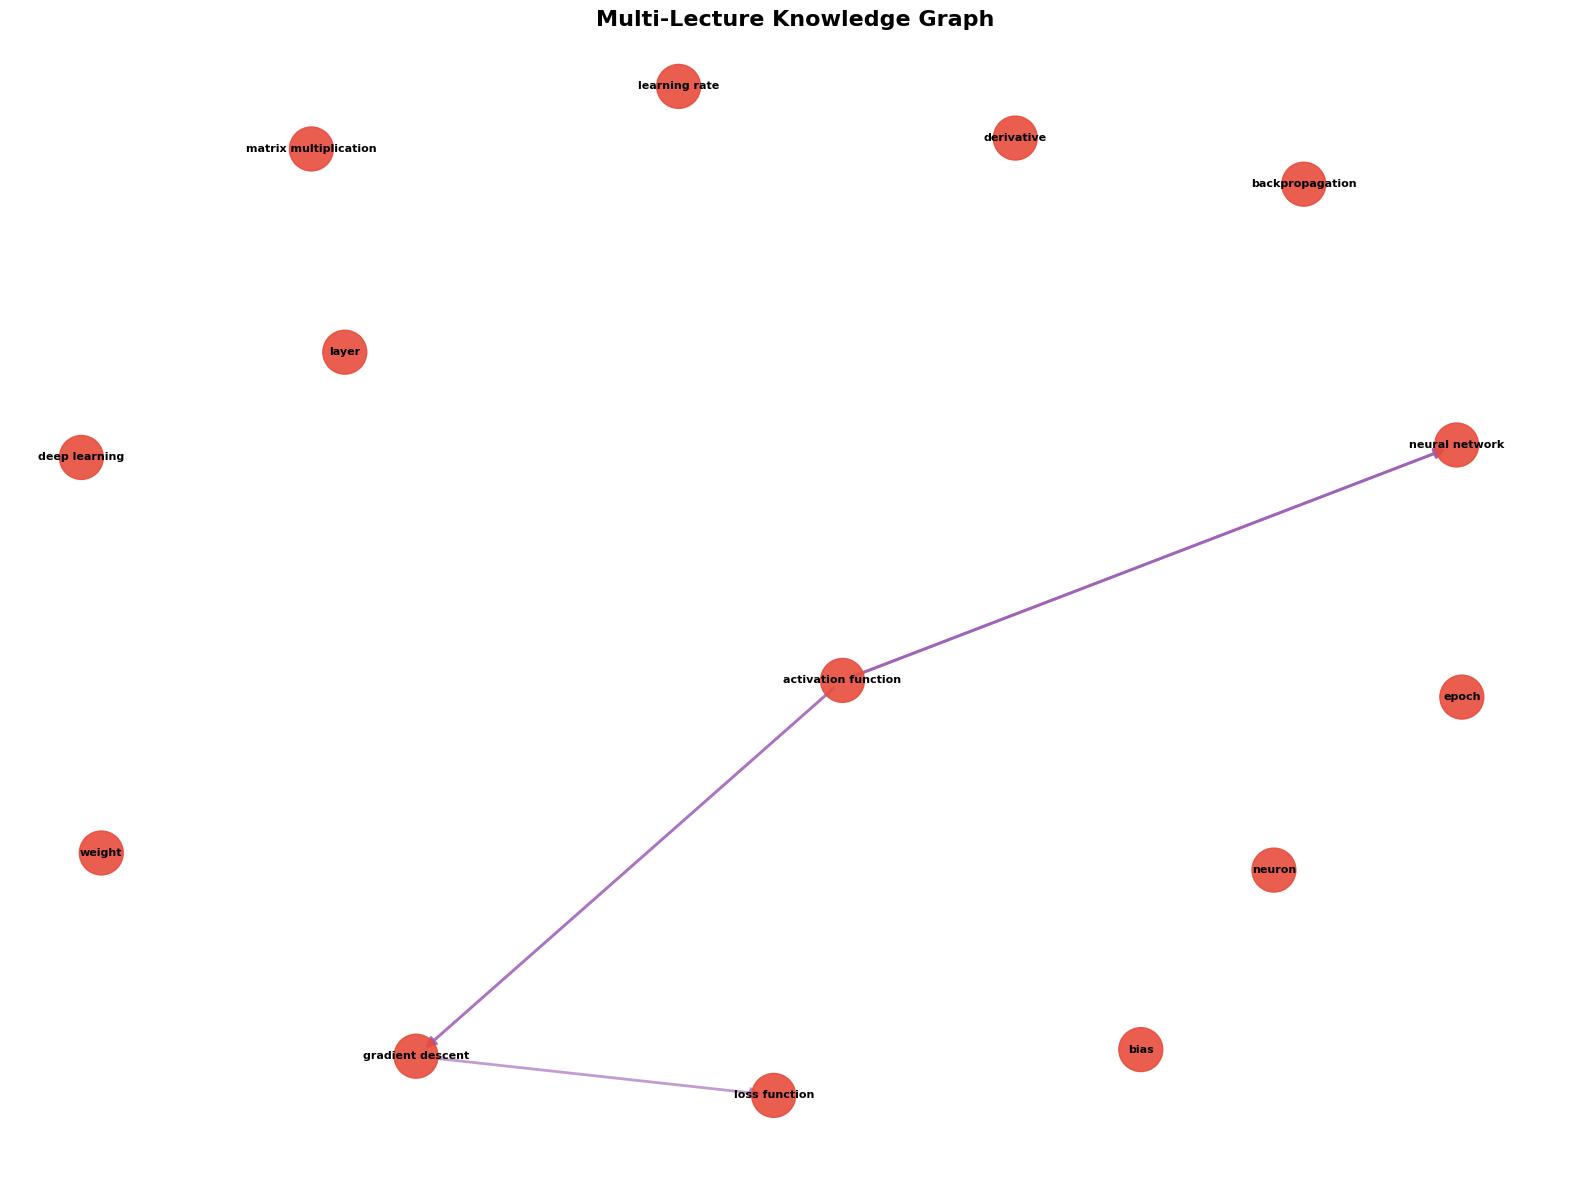


✓ Knowledge graph construction complete!
✓ Graph saved to: /content/drive/MyDrive/Data_mining/data/processed/knowledge/knowledge_graph.pkl
✓ Visualization saved to: /content/drive/MyDrive/Data_mining/data/processed/knowledge/knowledge_graph.png


In [ ]:
print("\n" + "=" * 80)
print("VISUALIZING KNOWLEDGE GRAPH")
print("=" * 80)

viz_path = f"{Config.KNOWLEDGE_DIR}/knowledge_graph.png"
kg_builder.visualize(viz_path)

print("\n✓ Knowledge graph construction complete!")
print(f"✓ Graph saved to: {graph_path}")
print(f"✓ Visualization saved to: {viz_path}")

## SECTION 6: EXPORT FOR ANALYSIS

In [ ]:
# Export concepts to DataFrame
concepts_data = []
for node, data in kg_builder.graph.nodes(data=True):
    concepts_data.append({
        'concept': data['name'],
        'definition': data['definition'],
        'first_seen': data['first_seen'],
        'num_lectures': len(data['lectures']),
        'lectures': ', '.join(data['lectures']),
        'has_evolution': len(data.get('definitions', [])) > 1
    })

df_concepts = pd.DataFrame(concepts_data)
df_concepts.to_csv(f"{Config.KNOWLEDGE_DIR}/concepts_summary.csv", index=False)
print(f"\n✓ Exported concepts to CSV")

# Export relationships to DataFrame
relationships_data = []
for u, v, data in kg_builder.graph.edges(data=True):
    relationships_data.append({
        'source': kg_builder.graph.nodes[u]['name'],
        'target': kg_builder.graph.nodes[v]['name'],
        'type': data.get('type', 'unknown'),
        'lecture': data.get('lecture', 'unknown')
    })

df_relationships = pd.DataFrame(relationships_data)
df_relationships.to_csv(f"{Config.KNOWLEDGE_DIR}/relationships_summary.csv", index=False)
print(f"✓ Exported relationships to CSV")


✓ Exported concepts to CSV
✓ Exported relationships to CSV


# Q/A ON KNOWLEDGE GRAPH USING LLM

Question Answering system that:
1. Retrieves relevant concepts from knowledge graph
2. Extracts evidence from anchor frames
3. Performs multi-hop reasoning
4. Generates answers with citations
5. Supports cross-lecture queries

Uses HuggingFace LLM (Mistral/Llama) or rule-based generation

## SECTION 1: IMPORT

In [ ]:
import json
import os
from typing import List, Dict, Tuple
import requests
import re
print("=" * 80)
print("GRAPH-AUGMENTED QA SYSTEM")
print("=" * 80)

# Ollama is not being used, so we remove the related checks.
LLM_AVAILABLE = False # This will be set to True after HuggingFace model loading

print("\n⚠️  Ollama not detected - will use rule-based answers initially, then try HuggingFace LLM")


GRAPH-AUGMENTED QA SYSTEM

⚠️  Ollama not detected - will use rule-based answers initially, then try HuggingFace LLM


## SECTION 2: QA SYSTEM

In [ ]:
class GraphAugmentedQA:
    """Question answering with knowledge graph reasoning"""

    def __init__(self, kg_builder, use_ollama=False): # Removed USE_OLLAMA_GLOBAL
        self.kg = kg_builder
        self.use_ollama = False # Explicitly set to False
        self.embedder = kg_builder.embedder  # Reuse embedder

    def answer_question(self, question: str) -> Dict:
        """
        Answer a question using knowledge graph + evidence

        Returns dictionary with:
        - answer: Generated answer
        - reasoning_path: Concepts used
        - evidence: Supporting evidence from anchors
        - citations: Lecture references
        """

        print(f"\n{'='*60}")
        print(f"Question: {question}")
        print(f"{'='*60}")

        # Step 1: Identify question type
        q_type = self._classify_question(question)
        print(f"Question type: {q_type}")

        # Step 2: Retrieve relevant concepts
        relevant_concepts = self._retrieve_concepts(question)
        print(f"Retrieved {len(relevant_concepts)} relevant concepts")

        if not relevant_concepts:
            return {
                'question': question,
                'answer': "I don't have enough information to answer this question based on the lectures.",
                'reasoning_path': [],
                'evidence': [],
                'citations': []
            }

        # Step 3: Extract subgraph
        subgraph_info = self._extract_subgraph(relevant_concepts)
        print(f"Extracted subgraph with {len(subgraph_info['nodes'])} nodes")

        # Step 4: Get evidence from anchors
        evidence = self._gather_evidence(relevant_concepts)
        print(f"Gathered {len(evidence)} evidence pieces")

        # Step 5: Generate answer
        answer = self._generate_answer(
            question,
            q_type,
            subgraph_info,
            evidence
        )

        # Step 6: Extract citations
        citations = self._extract_citations(relevant_concepts)

        result = {
            'question': question,
            'answer': answer,
            'question_type': q_type,
            'reasoning_path': [c['name'] for c in relevant_concepts],
            'evidence': evidence,
            'citations': citations,
            'subgraph': subgraph_info
        }

        print(f"\n✓ Answer generated")
        return result

    def _classify_question(self, question: str) -> str:
        """Classify question type"""

        q_lower = question.lower()

        if any(word in q_lower for word in ['what is', 'define', 'definition']):
            return 'definition'
        elif any(word in q_lower for word in ['prerequisite', 'before', 'first need']):
            return 'prerequisite'
        elif any(word in q_lower for word in ['how', 'explain', 'describe']):
            return 'explanation'
        elif any(word in q_lower for word in ['evolve', 'change', 'across lecture']):
            return 'evolution'
        elif any(word in q_lower for word in ['difference', 'compare', 'versus', 'vs']):
            return 'comparison'
        else:
            return 'general'

    def _retrieve_concepts(self, question: str, top_k: int = 5) -> List[Dict]:
        """Retrieve relevant concepts using semantic search"""

        # Get question embedding
        question_embedding = self.embedder.encode([question])[0]

        # Score all concepts
        scores = []
        for node, data in self.kg.graph.nodes(data=True):
            # Combine name and definition for matching
            text = f"{data['name']} {data['definition']}"
            text_embedding = self.embedder.encode([text])[0]

            # Compute similarity
            from sklearn.metrics.pairwise import cosine_similarity
            score = cosine_similarity(
                [question_embedding],
                [text_embedding]
            )[0][0]

            scores.append({
                'node_id': node,
                'name': data['name'],
                'definition': data['definition'],
                'lectures': data.get('lectures', []),
                'score': score
            })

        # Sort by score
        scores.sort(key=lambda x: x['score'], reverse=True)

        # Return top-k
        return scores[:top_k]

    def _extract_subgraph(self, concepts: List[Dict]) -> Dict:
        """Extract subgraph around relevant concepts"""

        import networkx as nx

        # Get concept nodes
        concept_nodes = [c['node_id'] for c in concepts]

        # Include neighbors
        all_nodes = set(concept_nodes)
        for node in concept_nodes:
            # Add predecessors (prerequisites)
            all_nodes.update(self.kg.graph.predecessors(node))
            # Add successors (dependents)
            all_nodes.update(self.kg.graph.successors(node))

        # Create subgraph
        subgraph = self.kg.graph.subgraph(all_nodes)

        # Extract node and edge information
        nodes_info = []
        for node in subgraph.nodes():
            data = self.kg.graph.nodes[node]
            nodes_info.append({
                'id': node,
                'name': data['name'],
                'definition': data['definition'],
                'lectures': data.get('lectures', [])
            })

        edges_info = []
        for u, v, data in subgraph.edges(data=True):
            edges_info.append({
                'source': self.kg.graph.nodes[u]['name'],
                'target': self.kg.graph.nodes[v]['name'],
                'type': data.get('type', 'related_to')
            })

        return {
            'nodes': nodes_info,
            'edges': edges_info
        }

    def _gather_evidence(self, concepts: List[Dict]) -> List[Dict]:
        """Gather evidence from anchor frames for relevant concepts"""

        evidence = []

        for concept in concepts[:3]:  # Top 3 concepts
            lectures = concept.get('lectures', [])

            for lecture in lectures:
                # Find where this concept was introduced
                node_data = self.kg.graph.nodes[concept['node_id']]

                # Get definition from this lecture
                definitions = node_data.get('definitions', [])
                for def_entry in definitions:
                    if def_entry['lecture'] == lecture:
                        evidence.append({
                            'concept': concept['name'],
                            'lecture': lecture,
                            'text': def_entry['definition']
                        })
                        break

        return evidence

    def _generate_answer(
        self,
        question: str,
        q_type: str,
        subgraph: Dict,
        evidence: List[Dict]
    ) -> str:
        """Generate answer using LLM or rules"""

        # With Ollama removed, this method directly calls rule-based.
        return self._generate_with_rules(question, q_type, subgraph, evidence)

    # Removed _generate_with_ollama method as it's no longer used.

    def _generate_with_rules(
        self,
        question: str,
        q_type: str,
        subgraph: Dict,
        evidence: List[Dict]
    ) -> str:
        """Generate answer using rules (fallback)"""

        if q_type == 'definition':
            # Find the main concept
            if subgraph['nodes']:
                concept = subgraph['nodes'][0]
                lectures = ', '.join(concept['lectures'])
                return f"{concept['name'].title()} is defined as: {concept['definition']} (Covered in lectures: {lectures})"

        elif q_type == 'prerequisite':
            # Find prerequisites
            if subgraph['edges']:
                prereq_edges = [e for e in subgraph['edges'] if e['type'] == 'prerequisite_of']
                if prereq_edges:
                    prereqs = [e['source'] for e in prereq_edges]
                    return f"The prerequisites are: {', '.join(prereqs)}"
                else:
                    return "No explicit prerequisites were identified in the lectures."
            else:
                return "No prerequisite relationships found."

        elif q_type == 'evolution':
            # Track concept evolution
            if subgraph['nodes']:
                concept = subgraph['nodes'][0]
                if len(concept['lectures']) > 1:
                    lectures_str = ' → '.join(concept['lectures'])
                    return f"The concept '{concept['name']}' appears across lectures: {lectures_str}. {concept['definition']}"
                else:
                    return f"The concept '{concept['name']}' appears in {concept['lectures'][0]} only."

        # General answer
        if subgraph['nodes']:
            main_concept = subgraph['nodes'][0]
            answer = f"Based on the lectures, {main_concept['definition']}"

            # Add related concepts
            if len(subgraph['nodes']) > 1:
                related = [n['name'] for n in subgraph['nodes'][1:3]]
                answer += f" Related concepts include: {', '.join(related)}."

            return answer

        return "I cannot find enough information to answer this question."

    def _format_context(self, subgraph: Dict, evidence: List[Dict]) -> str:
        """Format subgraph and evidence as text context"""

        context = "Concepts:\n"
        for node in subgraph['nodes'][:5]:
            lectures = ', '.join(node['lectures'])
            context += f"- {node['name']}: {node['definition']} (Lectures: {lectures})\n"

        if subgraph['edges']:
            context += "\nRelationships:\n"
            for edge in subgraph['edges'][:5]:
                context += f"- {edge['source']} --[{edge['type']}]--> {edge['target']}\n"

        if evidence:
            context += "\nEvidence from lectures:\n"
            for ev in evidence[:3]:
                context += f"- [{ev['lecture']}] {ev['concept']}: {ev['text']}\n"

        return context

    def _extract_citations(self, concepts: List[Dict]) -> List[str]:
        """Extract lecture citations"""

        citations = set()
        for concept in concepts:
            for lecture in concept.get('lectures', []):
                citations.add(lecture)

        return sorted(list(citations))

    def print_answer(self, result: Dict):
        """Pretty print answer result"""

        print(f"\n{'='*60}")
        print(f"QUESTION: {result['question']}")
        print(f"{'='*60}")
        print(f"\nANSWER:")
        print(f"{result['answer']}")
        print(f"\nREASONING PATH:")
        for concept in result['reasoning_path']:
            print(f"  → {concept}")
        print(f"\nCITATIONS:")
        for citation in result['citations']:
            print(f"  • {citation}")
        print(f"{'='*60}\n")


## SECTION 3: CREATE TEST QUESTIONS

In [ ]:
def create_test_questions() -> List[Dict]:
    """Create test questions for evaluation"""

    questions = [
        {
            'id': 1,
            'question': 'What is a neural network?',
            'type': 'definition',
            'difficulty': 'easy'
        },
        {
            'id': 2,
            'question': 'What is gradient descent?',
            'type': 'definition',
            'difficulty': 'easy'
        },
        {
            'id': 3,
            'question': 'What are the prerequisites for understanding backpropagation?',
            'type': 'prerequisite',
            'difficulty': 'medium'
        },
        {
            'id': 4,
            'question': 'How does the concept of activation function appear across the lectures?',
            'type': 'evolution',
            'difficulty': 'medium'
        },
        {
            'id': 5,
            'question': 'Explain the relationship between gradient descent and loss function.',
            'type': 'explanation',
            'difficulty': 'medium'
        },
        {
            'id': 6,
            'question': 'What is the role of weights in a neural network?',
            'type': 'explanation',
            'difficulty': 'easy'
        },
        {
            'id': 7,
            'question': 'What is deep learning?',
            'type': 'definition',
            'difficulty': 'easy'
        },
        {
            'id': 8,
            'question': 'How is a layer different from a neuron?',
            'type': 'comparison',
            'difficulty': 'medium'
        },
        {
            'id': 9,
            'question': 'What is the purpose of a learning rate?',
            'type': 'explanation',
            'difficulty': 'medium'
        },
        {
            'id': 10,
            'question': 'Explain what an epoch is in neural network training.',
            'type': 'explanation',
            'difficulty': 'easy'
        }
    ]

    return questions


## SECTION 4: INITIALIZE QA SYSTEM

In [ ]:

print("\n" + "=" * 80)
print("INITIALIZING QA SYSTEM")
print("=" * 80)

# Load knowledge graph
graph_path = f"{Config.KNOWLEDGE_DIR}/knowledge_graph.pkl"

if not os.path.exists(graph_path):
    print("❌ Knowledge graph not found!")
    print("Please run the knowledge graph construction notebook first.")
else:
    # Load graph
    import pickle
    with open(graph_path, 'rb') as f:
        graph_data = pickle.load(f)

    # Recreate KG builder
    from sentence_transformers import SentenceTransformer

    kg_builder = KnowledgeGraphBuilder()
    kg_builder.graph = graph_data['graph']
    kg_builder.concept_embeddings = graph_data['embeddings']
    kg_builder.lecture_order = graph_data['lecture_order']
    kg_builder.embedder = SentenceTransformer('all-MiniLM-L6-v2')  # Reload embedder

    print(f"✓ Loaded knowledge graph")
    print(f"  Concepts: {kg_builder.graph.number_of_nodes()}")
    print(f"  Relationships: {kg_builder.graph.number_of_edges()}")

    # Initialize QA system
    qa_system = GraphAugmentedQA(kg_builder)

    print("\n✓ QA System initialized!")



## SECTION 5: DEMO ANSWER TEST QUESTIONS

In [ ]:
print("\n" + "=" * 80)
print("DEMO: ANSWERING TEST QUESTIONS")
print("=" * 80)

# Create test questions
test_questions = create_test_questions()

# Answer first 5 questions as demo
results = []

for q_data in test_questions[:5]:
    result = qa_system.answer_question(q_data['question'])
    results.append(result)
    qa_system.print_answer(result)


## SECTION 6: SAVE RESULTS

In [ ]:
# Save all results
results_path = f"{Config.KNOWLEDGE_DIR}/qa_results.json"

with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n✓ Saved QA results to: {results_path}")


## EVALUATION FRAMEWORK

In [ ]:

def evaluate_qa_system(results: List[Dict]) -> Dict:
    """Simple evaluation of QA results"""

    metrics = {
        'total_questions': len(results),
        'answered': 0,
        'with_citations': 0,
        'with_reasoning_path': 0,
        'avg_concepts_used': 0,
        'by_type': {}
    }

    total_concepts = 0

    for result in results:
        # Check if answered
        if result['answer'] and 'cannot find' not in result['answer'].lower():
            metrics['answered'] += 1

        # Check citations
        if result['citations']:
            metrics['with_citations'] += 1

        # Check reasoning path
        if result['reasoning_path']:
            metrics['with_reasoning_path'] += 1
            total_concepts += len(result['reasoning_path'])

        # Count by type
        q_type = result.get('question_type', 'unknown')
        if q_type not in metrics['by_type']:
            metrics['by_type'][q_type] = {'total': 0, 'answered': 0}
        metrics['by_type'][q_type]['total'] += 1
        if 'cannot find' not in result['answer'].lower():
            metrics['by_type'][q_type]['answered'] += 1

    if metrics['answered'] > 0:
        metrics['avg_concepts_used'] = total_concepts / metrics['answered']

    return metrics

# Evaluate
metrics = evaluate_qa_system(results)

print("\n" + "=" * 80)
print("QA SYSTEM EVALUATION")
print("=" * 80)
print(f"  Questions answered: {metrics['answered']}/{metrics['total_questions']}")
print(f"  With citations: {metrics['with_citations']}/{metrics['total_questions']}")
print(f"  With reasoning: {metrics['with_reasoning_path']}/{metrics['total_questions']}")
print(f"  Avg concepts used: {metrics['avg_concepts_used']:.1f}")

print("\n  By question type:")
for q_type, stats in metrics['by_type'].items():
    print(f"    {q_type}: {stats['answered']}/{stats['total']}")


## SECTION 7: LOAD LLM FOR ANSWER GENERATION

In [ ]:

print("=" * 80)
print("LOADING LLM FOR ANSWER GENERATION")
print("=" * 80)

!pip install -q transformers>=4.35.0 accelerate bitsandbytes

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# ============================================================================
# LOAD MISTRAL-7B (Quantized for Colab)
# ============================================================================

print("\nLoading Mistral-7B-Instruct-v0.2 (4-bit quantized)...")
print("This will take 2-3 minutes on first run...")

# Configure 4-bit quantization
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# Load Mistral model
try:
    llm_model = AutoModelForCausalLM.from_pretrained(
        "mistralai/Mistral-7B-Instruct-v0.2",
        quantization_config=quantization_config,
        device_map="auto",
        torch_dtype=torch.float16
    )

    llm_tokenizer = AutoTokenizer.from_pretrained(
        "mistralai/Mistral-7B-Instruct-v0.2"
    )

    print("✓ Mistral-7B loaded successfully!")
    LLM_AVAILABLE = True

except Exception as e:
    print(f"⚠️  Could not load LLM: {e}")
    print("Will use rule-based generation")
    LLM_AVAILABLE = False
    llm_model = None
    llm_tokenizer = None


## SECTION 8: LLM ANSWER GENERATOR

In [ ]:
class LLMAnswerGenerator:
    """Generate answers using HuggingFace LLM"""

    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer
        self.available = model is not None

    def generate_answer(
        self,
        question: str,
        context: str,
        max_tokens: int = 300
    ) -> str:
        """Generate answer using LLM"""

        if not self.available:
            return None

        # Create prompt
        prompt = f"""You are an AI tutor answering questions about neural networks based on lecture content.\n\nQuestion: {question}\n\nKnowledge Graph Context:\n{context}\n\nInstructions:\n1. Answer the question clearly and concisely in 2-3 sentences\n2. Use information from the knowledge graph context\n3. Cite specific lectures when referencing information\n4. Be direct and avoid unnecessary explanations\n\nAnswer:"""

        try:
            # Tokenize
            inputs = self.tokenizer(
                prompt,
                return_tensors="pt",
                truncation=True,
                max_length=2048
            ).to(self.model.device)

            # Generate
            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_new_tokens=max_tokens,
                    do_sample=True,
                    temperature=0.3,
                    top_p=0.9,
                    pad_token_id=self.tokenizer.eos_token_id
                )

            # Decode
            generated_text = self.tokenizer.decode(
                outputs[0],
                skip_special_tokens=True
            )

            # Extract answer (remove prompt)
            if "Answer:" in generated_text:
                answer = generated_text.split("Answer:")[-1].strip()
            else:
                # Try to extract after the context
                answer = generated_text[len(prompt):].strip()

            return answer

        except Exception as e:
            print(f"  LLM generation error: {e}")
            return None

# Initialize generator
if LLM_AVAILABLE:
    llm_generator = LLMAnswerGenerator(llm_model, llm_tokenizer)
    print("\n✓ LLM answer generator ready!")
else:
    llm_generator = None
    print("\n⚠️  Using rule-based generation")


## SECTION 9: UPDATED QA SYSTEM WITH LLM

In [ ]:
class ImprovedGraphAugmentedQA(GraphAugmentedQA):
    """Enhanced QA with HuggingFace LLM"""

    def __init__(self, kg_builder, llm_generator=None):
        super().__init__(kg_builder, use_ollama=False) # Ensure use_ollama is False
        self.llm_generator = llm_generator

    def _generate_answer(
        self,
        question: str,
        q_type: str,
        subgraph: Dict,
        evidence: List[Dict]
    ) -> str:
        """Generate answer using LLM or rules"""

        # Try LLM first
        if self.llm_generator and self.llm_generator.available:
            context = self._format_context(subgraph, evidence)
            answer = self.llm_generator.generate_answer(question, context)

            if answer:
                return answer

        # Fallback to rules
        return self._generate_with_rules(question, q_type, subgraph, evidence)


## SECTION 10: REINITIALIZE QA SYSTEM WITH LLM

In [ ]:
print("\n" + "=" * 80)
print("REINITIALIZING QA SYSTEM WITH LLM")
print("=" * 80)

# Reinitialize with LLM
qa_system_llm = ImprovedGraphAugmentedQA(kg_builder, llm_generator)

print("✓ Enhanced QA system ready with LLM support!")


In [ ]:


# ============================================================================
# TEST WITH LLM
# ============================================================================

print("\n" + "=" * 80)
print("TESTING QA WITH LLM")
print("=" * 80)

# Test questions
test_questions_llm = [
    "What is a neural network?",
    "What is gradient descent?",
    "Explain the role of activation functions.",
    "What are the prerequisites for understanding backpropagation?",
    "How does the concept of neural network appear across the lectures?"
]

# Answer with LLM
llm_results = []

for question in test_questions_llm:
    result = qa_system_llm.answer_question(question)
    llm_results.append(result)
    qa_system_llm.print_answer(result)

# ============================================================================
# SAVE RESULTS
# ============================================================================

# Save LLM results
llm_results_path = f"{Config.KNOWLEDGE_DIR}/qa_results_llm.json"

with open(llm_results_path, 'w') as f:
    json.dump(llm_results, f, indent=2)

print(f"\n✓ Saved LLM QA results to: {llm_results_path}")

# ============================================================================
# COMPARISON: RULE-BASED VS LLM
# ============================================================================

print("\n" + "=" * 80)
print("COMPARISON: RULE-BASED VS LLM ANSWERS")
print("=" * 80)

# Compare answers for same questions
comparison_question = "What is gradient descent?"

print(f"\nQuestion: {comparison_question}\n")

# Rule-based answer
result_rules = qa_system.answer_question(comparison_question)
print("RULE-BASED ANSWER:")
print(result_rules['answer'])

print("\n" + "-" * 60 + "\n")

# LLM answer
result_llm = qa_system_llm.answer_question(comparison_question)
print("LLM ANSWER:")
print(result_llm['answer'])

print("\n" + "=" * 80)


GRAPH-AUGMENTED QA SYSTEM

⚠️  Ollama not detected - will use rule-based answers initially, then try HuggingFace LLM

INITIALIZING QA SYSTEM
✓ Loaded knowledge graph
  Concepts: 14
  Relationships: 6

✓ QA System initialized!

DEMO: ANSWERING TEST QUESTIONS

Question: What is a neural network?
Question type: definition
Retrieved 5 relevant concepts
Extracted subgraph with 6 nodes
Gathered 9 evidence pieces

✓ Answer generated

QUESTION: What is a neural network?

ANSWER:
Layer is defined as: a fundamental building block of a neural network, consisting of a set of interconnected nodes or neurons, which process input data and generate output data. (Covered in lectures: neural_net_01, neural_net_02, neural_net_03)

REASONING PATH:
  → layer
  → neural network
  → neuron
  → activation function
  → backpropagation

CITATIONS:
  • neural_net_01
  • neural_net_02
  • neural_net_03


Question: What is gradient descent?
Question type: definition
Retrieved 5 relevant concepts
Extracted subgraph

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


⚠️  Could not load LLM: Using `bitsandbytes` 4-bit quantization requires the latest version of bitsandbytes: `pip install -U bitsandbytes`
Will use rule-based generation

⚠️  Using rule-based generation

REINITIALIZING QA SYSTEM WITH LLM
✓ Enhanced QA system ready with LLM support!

TESTING QA WITH LLM

Question: What is a neural network?
Question type: definition
Retrieved 5 relevant concepts
Extracted subgraph with 6 nodes
Gathered 9 evidence pieces

✓ Answer generated

QUESTION: What is a neural network?

ANSWER:
Layer is defined as: a fundamental building block of a neural network, consisting of a set of interconnected nodes or neurons, which process input data and generate output data. (Covered in lectures: neural_net_01, neural_net_02, neural_net_03)

REASONING PATH:
  → layer
  → neural network
  → neuron
  → activation function
  → backpropagation

CITATIONS:
  • neural_net_01
  • neural_net_02
  • neural_net_03


Question: What is gradient descent?
Question type: definition
Re

In [ ]:
result = qa_system_llm.answer_question("When was Activation function first mentioned")
qa_system_llm.print_answer(result)